# Research Project

**Dataset Description:**
https://www.kaggle.com/datasets/bharatmaheshwarids/5000-employee-dataset-of-an-organization-dummy

**Columns:**
- #: This field defines the Serial Number of the employee.
- Name: This field defines the name of the employee.
- Address: This field defines the Address of the employee.
- Salary: This field defines the Salary of the employee.
- DOJ: This field defines the Date of Joining of the employee.
- DOB: This field defines the Date of Birth of the employee.
- Age: This field defines the Age of the employee.
- Sex: This field defines the Gender of the employee.
- Dependents: This field defines the Number of Dependents Employee Having.
- HRA: This field defines the House Rent Allowance Employee gets on basic salary.
- DA: This field defines the Dearness Allowance Employee gets on basic salary.
- PF: This field defines the Employee Provident Fund getting Deducted from the salary.
- Gross Salary: This field defines the Grossing salary Employee gets.
- Insurance: This field defines which type of insurance the employee has; "none" means not insured.
- Marital Status: This field defines the marital status of the employee.
- In Company Years: This field defines the year of experience the employee has in the current organization.
- Year of Experience: This field defines the total years of experience the employee has.
- Department: This field defines the department where the employee is currently working.
- Position: This field defines the position the employee is currently working in / designation of the employee.

**Research Project tasks:**
- Use descriptive statistics (frequency analysis, statistical
characteristics, graphs)
- Perform analysis of relationship between variables (crosstabs, Chi-squared test, correlations)
- Perform regression analysis
- Perform PCA and cluster analysis

In [ ]:
!pip install factor_analyzer
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer, Rotator
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
from scipy import stats
from sklearn.decomposition import PCA
from matplotlib.gridspec import GridSpec
from scipy.stats import pointbiserialr

In [ ]:
path = kagglehub.dataset_download("bharatmaheshwarids/5000-employee-dataset-of-an-organization-dummy")
df = pd.read_csv(path + '/Dummy_5000_Employee_Details_Dataset.csv')

## Dataset Preprocessing

In [ ]:
columns_with_nan = df.columns[df.isnull().any()].tolist()

print("Columns with NaN values:", columns_with_nan)

Columns with NaN values: ['Dependents', 'Insurance', 'Marital Status']


In [ ]:
# Deletion of row with employee id (does not contain useful information)
df = df.drop(columns=['Unnamed: 0'])
# Based on data from Kaggle, NaN in the Insurance field means no insurance
df['Insurance'] = df['Insurance'].fillna('None')

# Deleting other empty values
df = df.dropna()

## Descriptive analysis

### Dataset Info

In [ ]:
df.head()

,Name,Address,Salary,DOJ,DOB,Age,Sex,Dependents,HRA,DA,PF,Gross Salary,Insurance,Marital Status,In Company Years,Year of Experience,Department,Position
0,VgwbPyBn,"jyNxKZtk St, piZQhYcARo, PUN 172813",149289.04,1998-04-27,1971-03-27,53,Other,2.0,8776.096,35233.666375,22142.724765,171156.077610,None,Widowed,26,32,Sales,Sales Director
1,pgdYaIWk,"PypVsqug St, iHyelKZbFc, BLR 580530",69761.64,2020-10-24,1997-12-12,26,Male,0.0,9302.836,16464.425985,10347.127918,85181.774067,Both,Single,3,5,Human Resources,HR Executive
2,eWgVBGVv,"pfQezTVa St, YfIaELfpUw, BLR 155186",107633.14,2020-07-22,1979-08-20,44,Female,2.0,13357.686,25402.468564,15964.273028,130429.021537,None,Divorced,3,23,Marketing,Senior Marketing Executive
3,LYDofRRu,"wcTsbmFr St, UdylzZFFCU, AMD 843852",147408.65,2007-03-27,1966-06-07,58,Male,1.0,6026.135,34789.876034,21863.823124,166360.837910,None,Married,17,37,Finance,Account Director
4,vhLFHcRg,"DdxKVhli St, cYOjpbMztB, BLR 713383",53447.06,2017-05-23,1992-11-19,31,Male,2.0,7554.294,12614.026326,7927.330359,65688.049967,Life,Married,7,10,Sales,Sales Executive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4877 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                4877 non-null   object 
 1   Address             4877 non-null   object 
 2   Salary              4877 non-null   float64
 3   DOJ                 4877 non-null   object 
 4   DOB                 4877 non-null   object 
 5   Age                 4877 non-null   int64  
 6   Sex                 4877 non-null   object 
 7   Dependents          4877 non-null   float64
 8   HRA                 4877 non-null   float64
 9   DA                  4877 non-null   float64
 10  PF                  4877 non-null   float64
 11  Gross Salary        4877 non-null   float64
 12  Insurance           4877 non-null   object 
 13  Marital Status      4877 non-null   object 
 14  In Company Years    4877 non-null   int64  
 15  Year of Experience  4877 non-null   int64  
 16  Department 

In [ ]:
df.describe()

,Salary,Age,Dependents,HRA,DA,PF,Gross Salary,In Company Years,Year of Experience
count,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000
mean,93896.638401,40.262046,1.951405,7992.015061,22160.520498,13926.859068,110122.314892,9.720935,19.262046
std,34321.021875,11.410395,1.303863,2332.824969,8100.095187,5090.534047,37899.273933,8.861402,11.410395
min,15042.700000,21.000000,0.000000,3127.273000,3550.223601,2231.150832,22624.827875,-1.000000,0.000000
25%,69538.040000,30.000000,1.000000,6246.717000,16411.654209,10313.963305,84225.361353,3.000000,9.000000
50%,96529.030000,40.000000,2.000000,7713.115000,22781.790535,14317.298464,110950.466480,7.000000,19.000000
75%,121915.310000,50.000000,3.000000,9533.383000,28773.199684,18082.621162,141758.285658,15.000000,29.000000
max,149991.340000,60.000000,4.000000,14787.699000,35399.416010,22246.890721,173050.731289,39.000000,39.000000


In [ ]:
numeric_features = df.select_dtypes(include=[np.number])
object_features = df.select_dtypes(exclude=[np.number])

In [ ]:
numeric_features.describe()

,Salary,Age,Dependents,HRA,DA,PF,Gross Salary,In Company Years,Year of Experience
count,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000
mean,93896.638401,40.262046,1.951405,7992.015061,22160.520498,13926.859068,110122.314892,9.720935,19.262046
std,34321.021875,11.410395,1.303863,2332.824969,8100.095187,5090.534047,37899.273933,8.861402,11.410395
min,15042.700000,21.000000,0.000000,3127.273000,3550.223601,2231.150832,22624.827875,-1.000000,0.000000
25%,69538.040000,30.000000,1.000000,6246.717000,16411.654209,10313.963305,84225.361353,3.000000,9.000000
50%,96529.030000,40.000000,2.000000,7713.115000,22781.790535,14317.298464,110950.466480,7.000000,19.000000
75%,121915.310000,50.000000,3.000000,9533.383000,28773.199684,18082.621162,141758.285658,15.000000,29.000000
max,149991.340000,60.000000,4.000000,14787.699000,35399.416010,22246.890721,173050.731289,39.000000,39.000000


In [ ]:
object_features.describe(include='object')

,Name,Address,DOJ,DOB,Sex,Insurance,Marital Status,Department,Position
count,4877,4877,4877,4877,4877,4877,4877,4877,4877
unique,4877,4877,3646,4056,3,4,4,5,40
top,VgwbPyBn,"jyNxKZtk St, piZQhYcARo, PUN 172813",2020-11-09,1979-12-21,Other,Both,Married,Human Resources,National Sales Manager
freq,1,1,6,5,1632,1263,2929,1008,196


### Frequency Analysis

In [ ]:
def analyze_column(df, column_name):
    print(f"Analysis for column: {column_name}")

    print("\nFrequency count:")
    print(df[column_name].value_counts().to_frame())

    print("\nNumber of unique values:")
    print(df[column_name].nunique())

    print("\nNormalized (percentages) value counts:")
    print(df[column_name].value_counts(normalize=True).to_frame())

    print("\nUnique values:")
    print(df[column_name].unique())

    print("="*50)

for column in df.columns:
    analyze_column(df, column)

Analysis for column: Name

Frequency count:
          count
Name           
VgwbPyBn      1
ZTaGzuLw      1
pzIsWAEY      1
wrwtNCyo      1
LYLtLNgW      1
...         ...
uvvAsjkA      1
PdFxYXBB      1
fYQWCXBq      1
WIBjCHxx      1
EWrIRxIJ      1

[4877 rows x 1 columns]

Number of unique values:
4877

Normalized (percentages) value counts:
          proportion
Name                
VgwbPyBn    0.000205
ZTaGzuLw    0.000205
pzIsWAEY    0.000205
wrwtNCyo    0.000205
LYLtLNgW    0.000205
...              ...
uvvAsjkA    0.000205
PdFxYXBB    0.000205
fYQWCXBq    0.000205
WIBjCHxx    0.000205
EWrIRxIJ    0.000205

[4877 rows x 1 columns]

Unique values:
['VgwbPyBn' 'pgdYaIWk' 'eWgVBGVv' ... 'gToCBVUH' 'dwTQETtZ' 'EWrIRxIJ']
Analysis for column: Address

Frequency count:
                                     count
Address                                   
jyNxKZtk St, piZQhYcARo, PUN 172813      1
ysmXxPFA St, OqgxNNWWjS, MUB 573694      1
KuDOgdWM St, PvqEtIYVTz, BLR 624300      1
JORu

### Missing values

In [ ]:
missing = (df.isna().sum() / len(df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)
missing = pd.DataFrame({'Percent of missing values' : missing})
missing

,Percent of missing values


### Dataset Vizualization

#### Heatmap

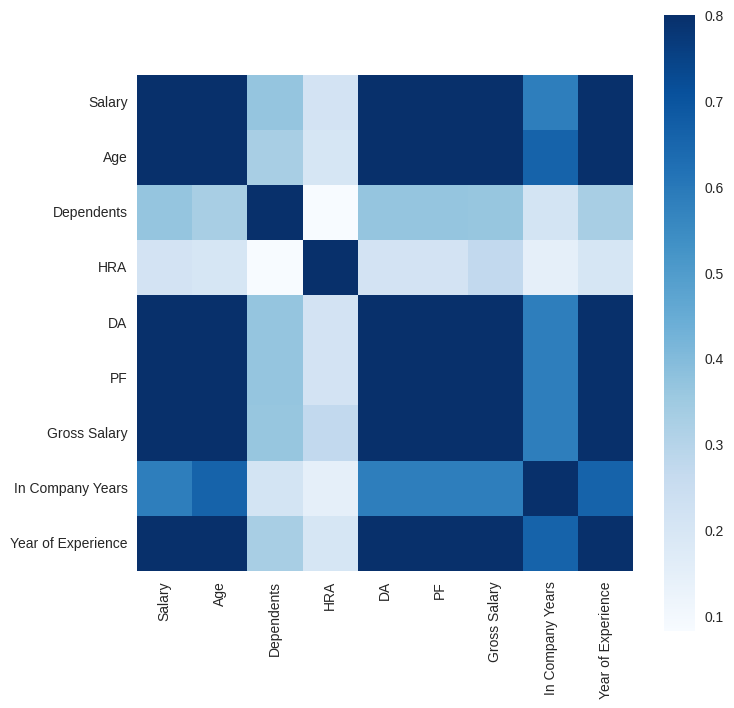

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 8))
sns.heatmap(corr, vmax=.8, square=True, cmap='Blues')
plt.show()

#### Name

A text variable with unique values. Visualization of this variable does not make sense.

#### Address

A text variable with unique values. Visualization of this variable does not make sense.

#### Salary

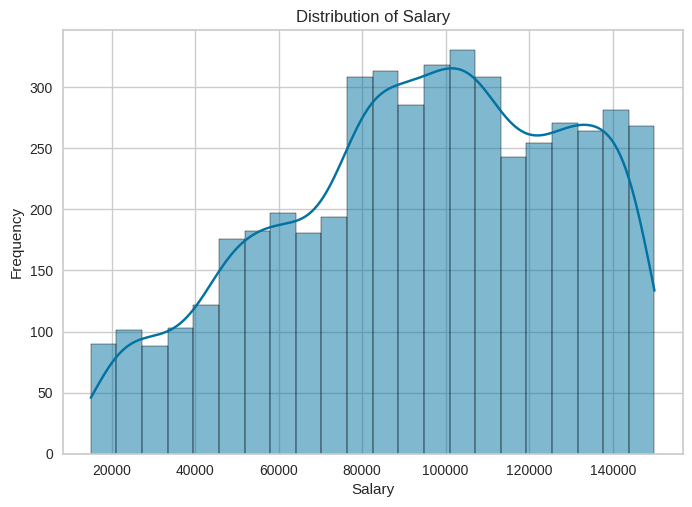

In [ ]:
sns.histplot(df['Salary'], kde=True)
plt.title('Distribution of Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### DOJ (Date of Joining)

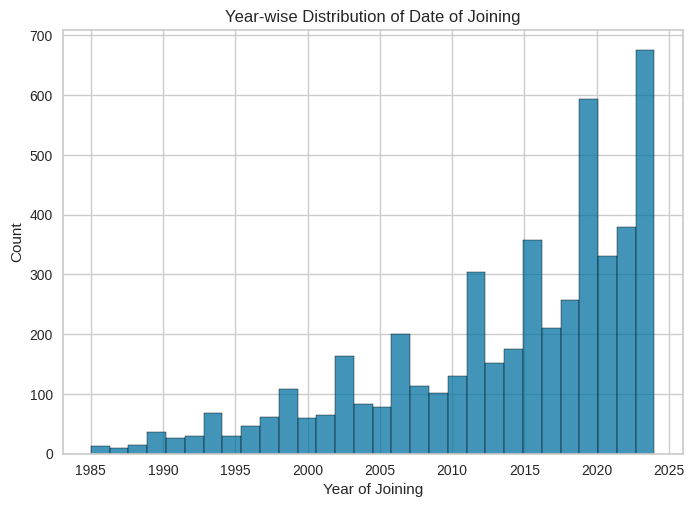

In [ ]:
df['DOJ'] = pd.to_datetime(df['DOJ'])
sns.histplot(df['DOJ'].dt.year, bins=30, kde=False)
plt.title('Year-wise Distribution of Date of Joining')
plt.xlabel('Year of Joining')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### DOB (Date of Birth)

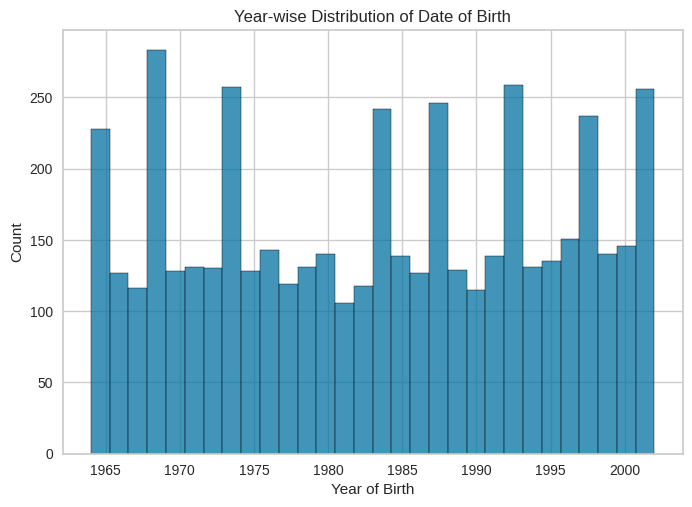

In [ ]:
df['DOB'] = pd.to_datetime(df['DOB'])
sns.histplot(df['DOB'].dt.year, bins=30, kde=False)
plt.title('Year-wise Distribution of Date of Birth')
plt.xlabel('Year of Birth')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### Age

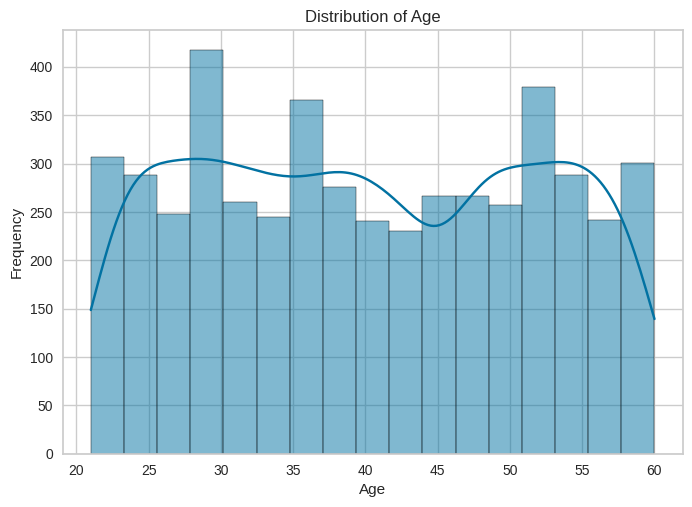

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Sex

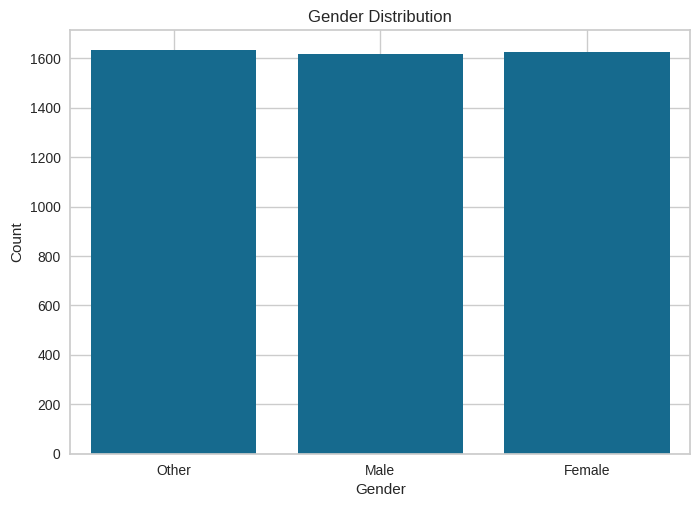

In [ ]:
sns.countplot(data=df, x='Sex')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### Dependents

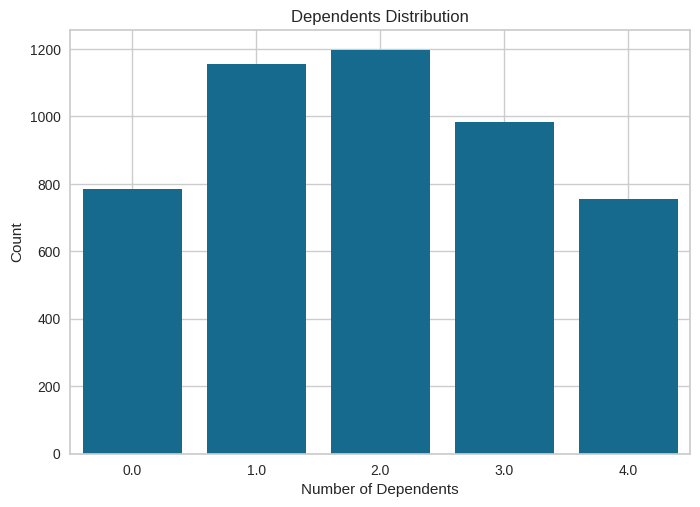

In [ ]:
sns.countplot(data=df, x='Dependents')
plt.title('Dependents Distribution')
plt.xlabel('Number of Dependents')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### HRA

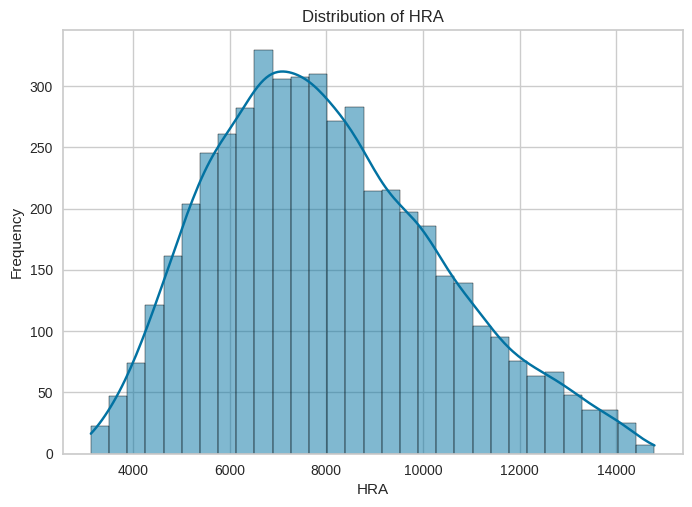

In [ ]:
sns.histplot(df['HRA'], kde=True)
plt.title('Distribution of HRA')
plt.xlabel('HRA')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### DA

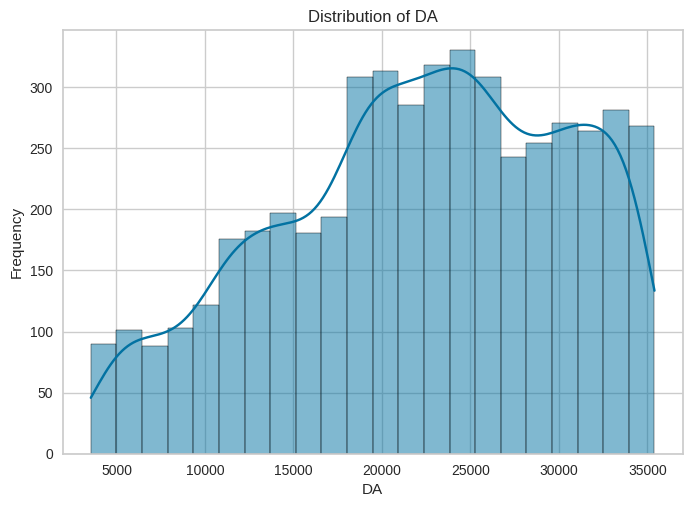

In [ ]:
sns.histplot(df['DA'], kde=True)
plt.title('Distribution of DA')
plt.xlabel('DA')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### PF

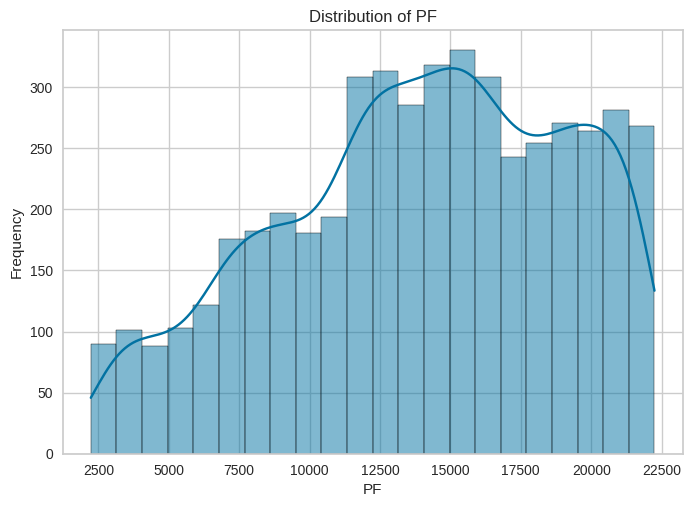

In [ ]:
sns.histplot(df['PF'], kde=True)
plt.title('Distribution of PF')
plt.xlabel('PF')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Gross Salary

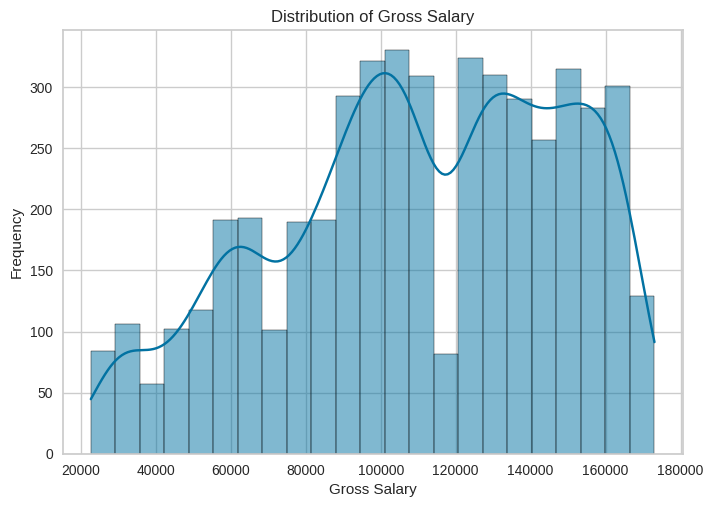

In [ ]:
sns.histplot(df['Gross Salary'], kde=True)
plt.title('Distribution of Gross Salary')
plt.xlabel('Gross Salary')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Insurance

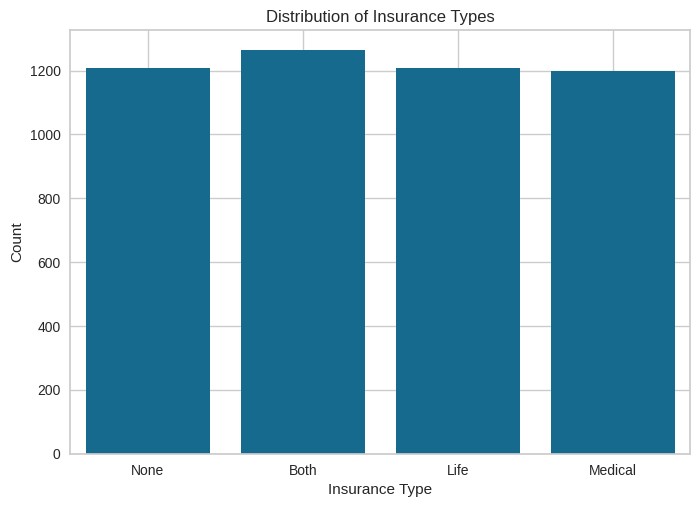

In [ ]:
sns.countplot(data=df, x='Insurance')
plt.title('Distribution of Insurance Types')
plt.xlabel('Insurance Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### Marital Status

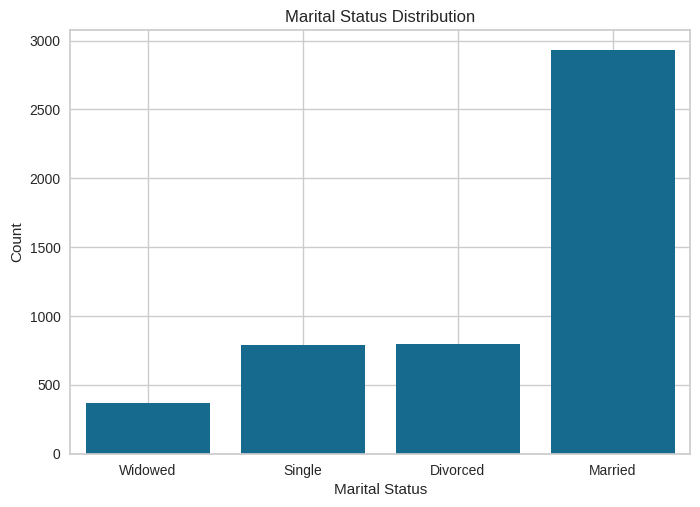

In [ ]:
sns.countplot(data=df, x='Marital Status')
plt.title('Marital Status Distribution')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.grid(True)
plt.show()

#### In Company Years

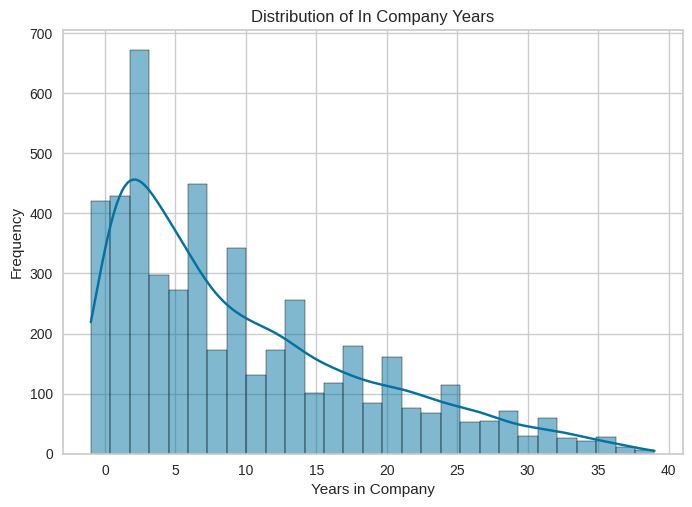

In [ ]:
sns.histplot(df['In Company Years'], kde=True)
plt.title('Distribution of In Company Years')
plt.xlabel('Years in Company')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Year of Experience

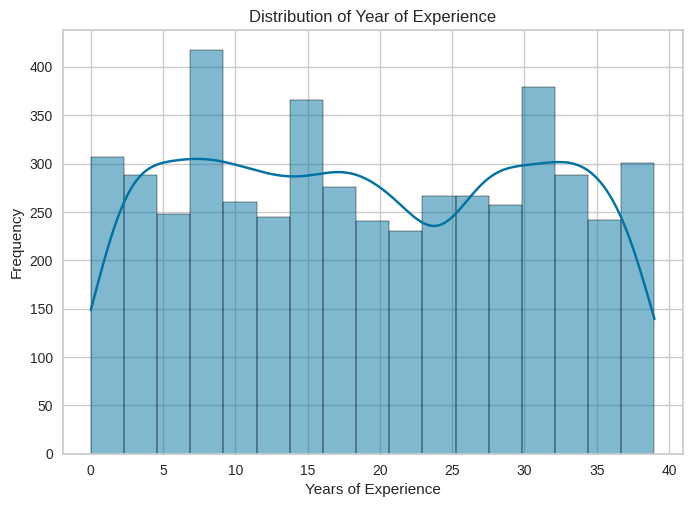

In [ ]:
sns.histplot(df['Year of Experience'], kde=True)
plt.title('Distribution of Year of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### Department

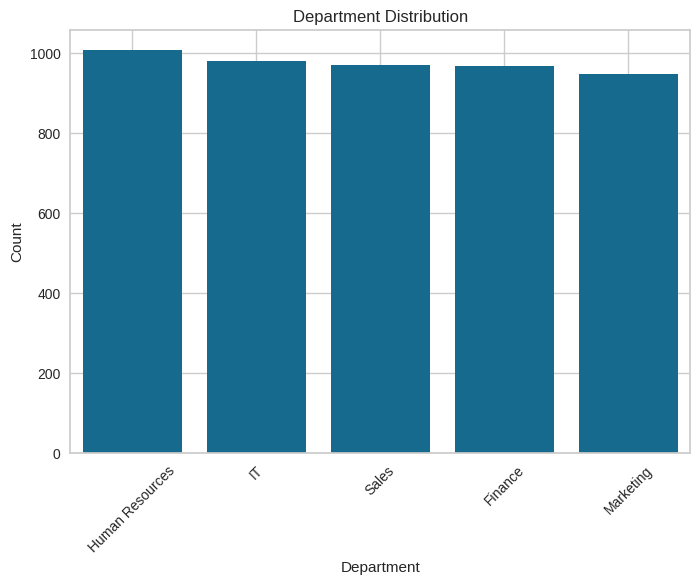

In [ ]:
sns.countplot(data=df, x='Department', order=df['Department'].value_counts().index)
plt.title('Department Distribution')
plt.xlabel('Department')
plt.ylabel('Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### Position

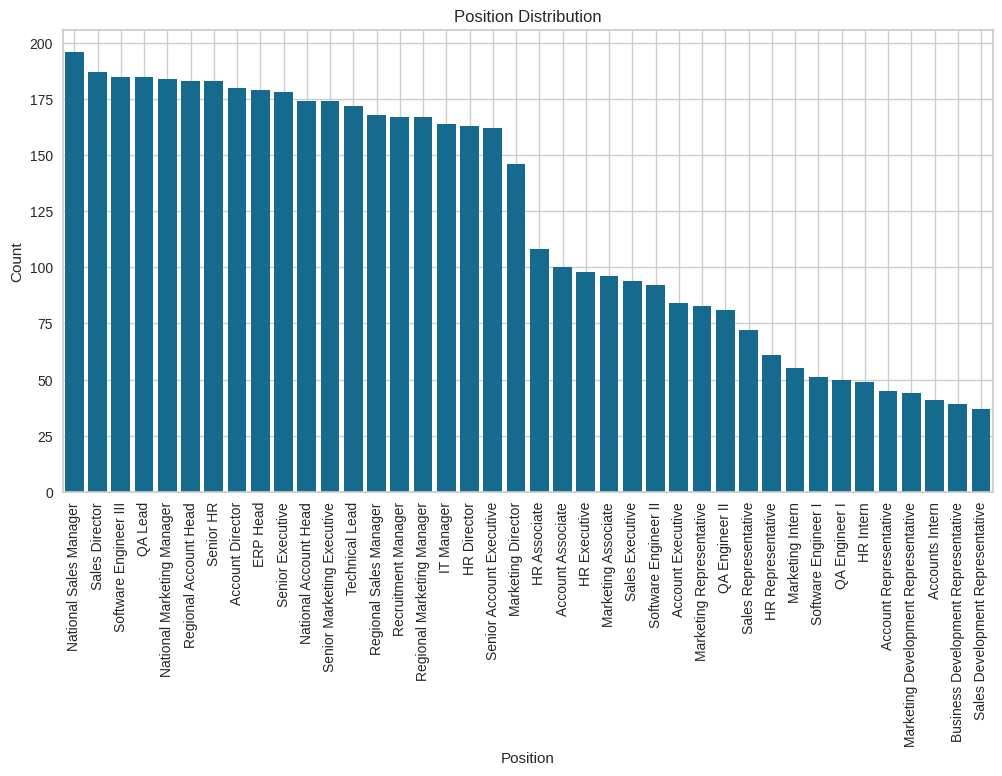

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Position', order=df['Position'].value_counts().index)
plt.title('Position Distribution')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

## Variables Relationship Analysis

### Sex - Marital Status (crosstab + chi-squared statistical test)

**H0:** There is a no relationship between sex and marital status.

**H1:** There is a relationship between sex and marital status.

In [ ]:
sex_and_marital_status_df = df.copy()
sex_and_marital_status_df['Marital Status'] = df['Marital Status'].apply(lambda x: 'Married' if x == 'Married' else 'Not Married')

In [ ]:
contingency_table = pd.crosstab(sex_and_marital_status_df['Sex'], sex_and_marital_status_df['Marital Status'])
contingency_table

Marital Status,Married,Not Married
Sex,,
Female,997,630
Male,972,646
Other,960,672


In [ ]:
stats.chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=2.0471385607453803, pvalue=0.3593101699471745, dof=2, expected_freq=array([[977.13409883, 649.86590117],
       [971.72893172, 646.27106828],
       [980.13696945, 651.86303055]]))

**Chi-squared statistical checklist:**
- both variables are categorical (+)
- observations are independent (+)
- expected value in 95% or more of the cells is greater than 5 (+)

Chi-squared statistical test is applicalable for this case.

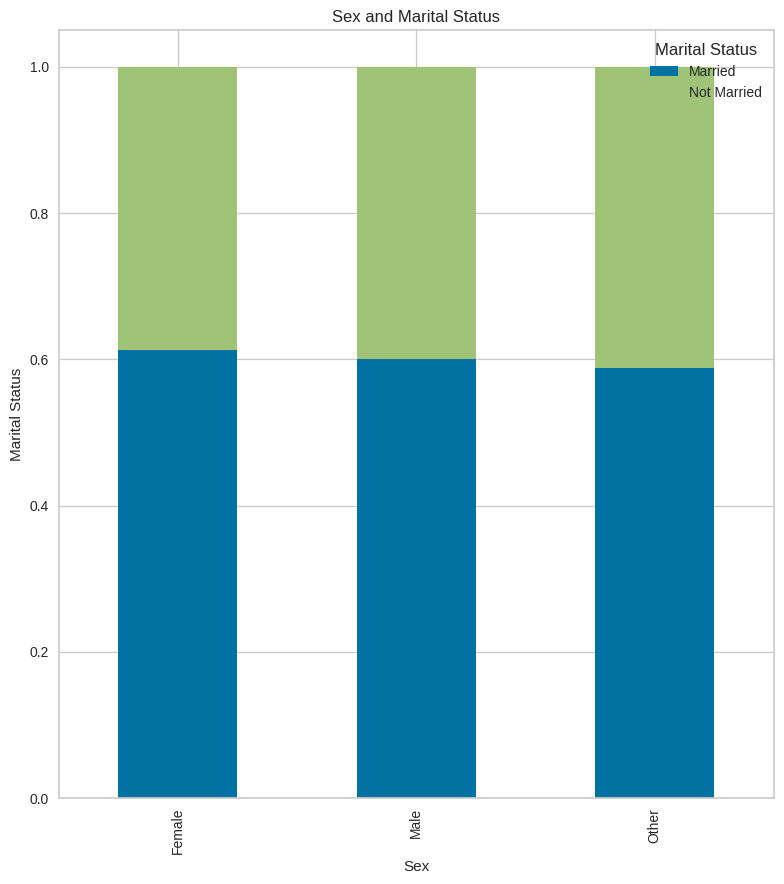

In [ ]:
fig = plt.figure(figsize=(8, 9))
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
pd.crosstab(sex_and_marital_status_df['Sex'], sex_and_marital_status_df['Marital Status'], normalize='index').plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Sex and Marital Status')
ax.set_xlabel('Sex')
ax.set_ylabel('Marital Status')

plt.tight_layout()
plt.show()

In [ ]:
print('chi2 = ', stats.chi2_contingency(contingency_table)[0], '   p-value =', stats.chi2_contingency(contingency_table)[1])

chi2 =  2.0471385607453803    p-value = 0.3593101699471745


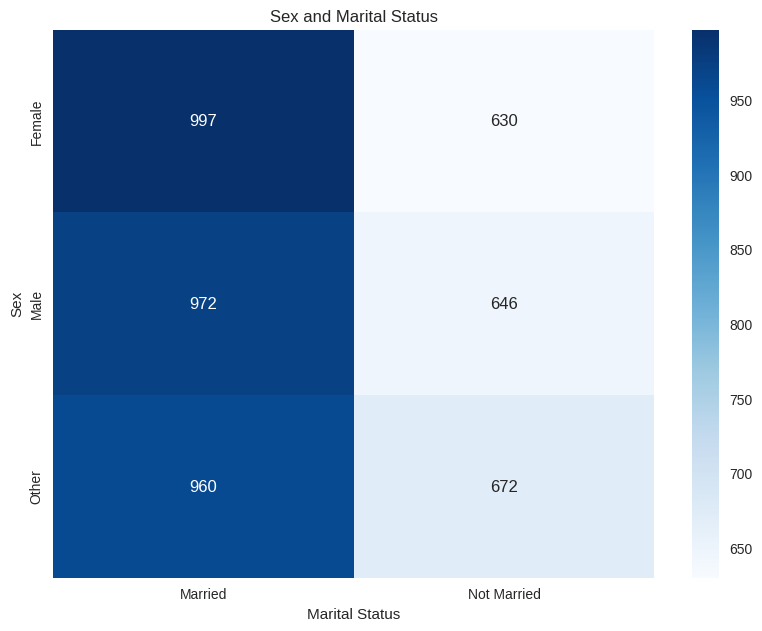

In [ ]:
fig = plt.figure(figsize=(16, 18))
gs = GridSpec(3, 2)

ax = fig.add_subplot(gs[2, 1])
heatmap_data3 = pd.crosstab(sex_and_marital_status_df['Sex'], sex_and_marital_status_df['Marital Status'])
sns.heatmap(heatmap_data3, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Sex and Marital Status')
ax.set_xlabel('Marital Status')
ax.set_ylabel('Sex')

plt.tight_layout()
plt.show()


**Conclusion:**
- p-value > 0.05
- p-value > 0.01


At both the 5% and 1% levels of significance, we fail to reject null hypothesis. This means that Sex and Marital Status are independent of each other.

### Sex - Insurance (crosstab + chi-squared statistical test)

1.   List item
2.   List item



**H0:** There is a no relationship between sex and having insurance.

**H1:** There is a relationship between sex and having insurance.

In [ ]:
# Convert insurance values
sex_and_insurance_df = df.copy()
sex_and_insurance_df['Insurance'] = df['Insurance'].apply(lambda x: 'Not Insured' if x.lower() == 'none' else 'Insured')

In [ ]:
contingency_table = pd.crosstab(sex_and_insurance_df['Sex'], sex_and_insurance_df['Insurance'])
contingency_table

Insurance,Insured,Not Insured
Sex,,
Female,1219,408
Male,1230,388
Other,1221,411


In [ ]:
stats.chi2_contingency(contingency_table)

Chi2ContingencyResult(statistic=0.7730381567229055, pvalue=0.6794177630733259, dof=2, expected_freq=array([[1224.33668239,  402.66331761],
       [1217.56407628,  400.43592372],
       [1228.09924134,  403.90075866]]))

**Chi-squared statistical checklist:**
- both variables are categorical (+)
- observations are independent (+)
- expected value in 95% or more of the cells is greater than 5 (+)

Chi-squared statistical test is applicalable for this case.

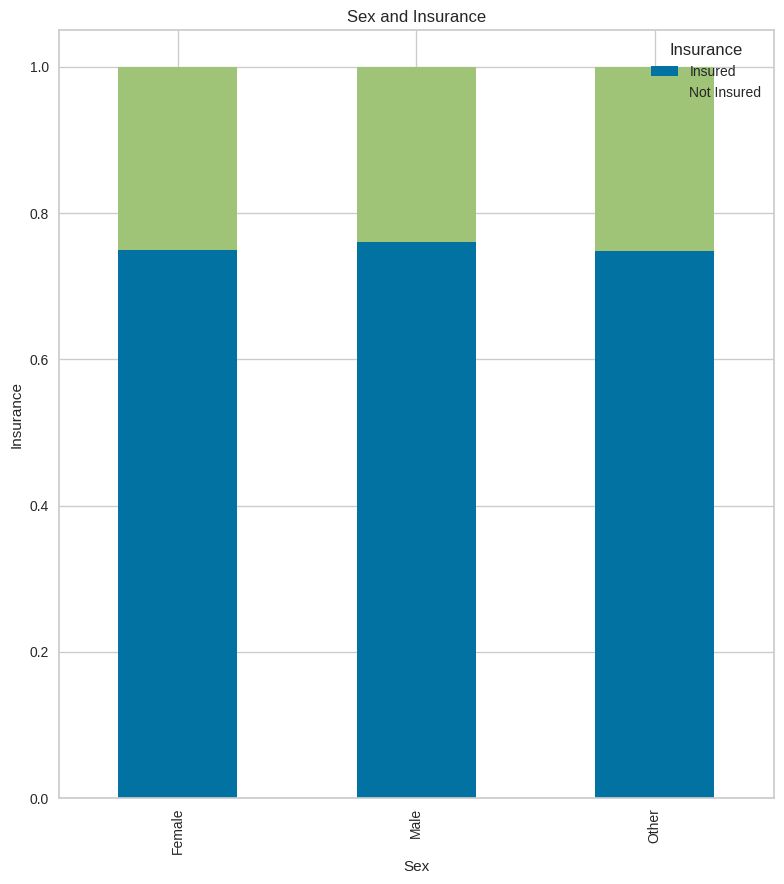

In [ ]:
fig = plt.figure(figsize=(8, 9))
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
pd.crosstab(sex_and_insurance_df['Sex'], sex_and_insurance_df['Insurance'], normalize='index').plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Sex and Insurance')
ax.set_xlabel('Sex')
ax.set_ylabel('Insurance')

plt.tight_layout()
plt.show()

In [ ]:
print('chi2 = ', stats.chi2_contingency(contingency_table)[0], '   p-value =', stats.chi2_contingency(contingency_table)[1])

chi2 =  0.7730381567229055    p-value = 0.6794177630733259


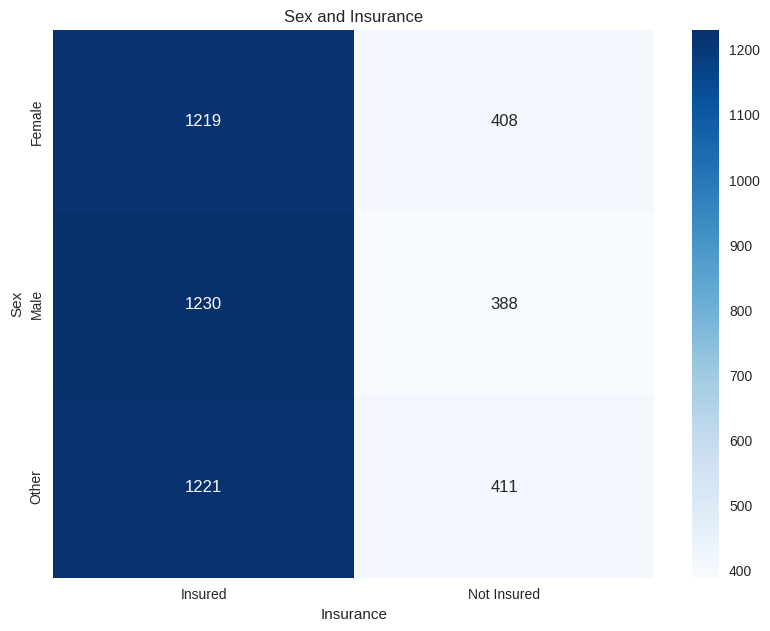

In [ ]:
fig = plt.figure(figsize=(16, 18))
gs = GridSpec(3, 2)

ax = fig.add_subplot(gs[2, 1])
heatmap_data3 = pd.crosstab(sex_and_insurance_df['Sex'], sex_and_insurance_df['Insurance'])
sns.heatmap(heatmap_data3, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Sex and Insurance')
ax.set_xlabel('Insurance')
ax.set_ylabel('Sex')

plt.tight_layout()
plt.show()

**Conclusion:**

- p-value > 0.05
- p-value > 0.01


At both the 5% and 1% levels of significance, we fail to reject null hypothesis. This means that Sex and Insurance are independent of each other.

### Salary - Age (Kolmogorov-Smirnov test + Spearman correlation)

**Hypotesis:**

- **H1:** There is a relationship between Salary and Age (r != 0)

- **H0:** There is no relationship between Salary and Age (r = 0)

The Kolmogorov-Smirnov test was chosen as a test to analyze the normal distribution because of the large size of the dataset (about 5000 records).

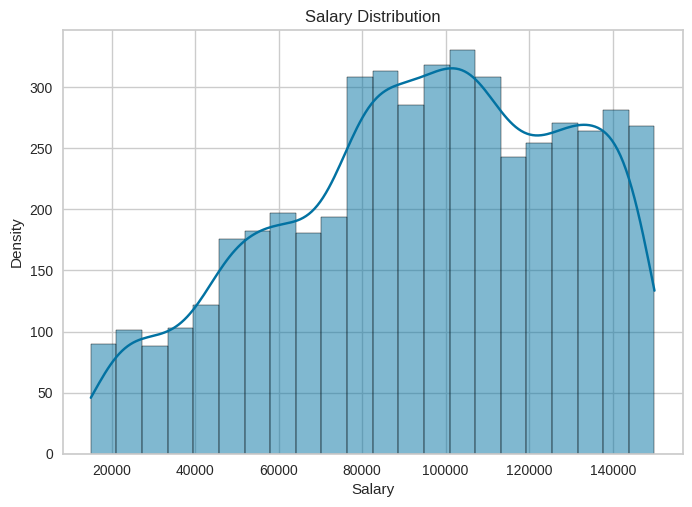

In [ ]:
sns.histplot(df["Salary"].dropna(), kde=True)
plt.xlabel('Salary')
plt.ylabel('Density')
plt.title('Salary Distribution')
plt.show()

In [ ]:
from scipy.stats import kstest
import numpy as np

def kolmogorov_smirnov_test(data, variable_name):
    data = data[variable_name].dropna()

    statistic, p_value = kstest(data, 'norm', args=(np.mean(data), np.std(data)))

    print(f"Kolmogorov-Smirnov Test for variable '{variable_name}':")
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")

    if p_value > 0.05:
        print(f"The data in '{variable_name}' is normally distributed (p > 0.05).")
    else:
        print(f"The data in '{variable_name}' is NOT normally distributed (p <= 0.05).")

kolmogorov_smirnov_test(df, "Salary")

Kolmogorov-Smirnov Test for variable 'Salary':
Statistic: 0.05106856921941294
P-value: 1.7082803317373517e-11
The data in 'Salary' is NOT normally distributed (p <= 0.05).


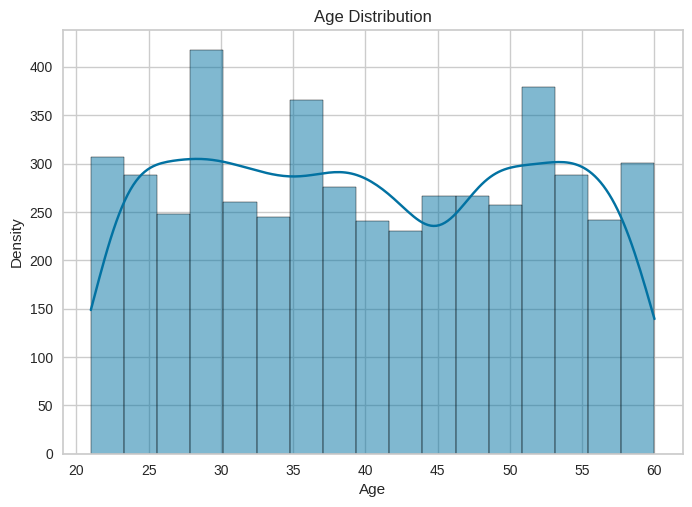

In [ ]:
sns.histplot(df["Age"].dropna(), kde=True)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution')
plt.show()

In [ ]:
from scipy.stats import kstest
import numpy as np

def kolmogorov_smirnov_test(data, variable_name):
    data = data[variable_name].dropna()

    statistic, p_value = kstest(data, 'norm', args=(np.mean(data), np.std(data)))

    print(f"Kolmogorov-Smirnov Test for variable '{variable_name}':")
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")

    if p_value > 0.05:
        print(f"The data in '{variable_name}' is normally distributed (p > 0.05).")
    else:
        print(f"The data in '{variable_name}' is NOT normally distributed (p <= 0.05).")

kolmogorov_smirnov_test(df, "Age")

Kolmogorov-Smirnov Test for variable 'Age':
Statistic: 0.082124743894886
P-value: 4.626073636433251e-29
The data in 'Age' is NOT normally distributed (p <= 0.05).


Based on the data obtained, we can say that both variables are not normally distributed.

'Salary' and 'Age' are continuous variables => This variables is not normally distributed => This variables is not ordinal => We choose Spearman's rank correlation

In [ ]:
df = df.dropna(subset=['Salary', 'Age'])

In [ ]:
spearman_corr, p_value = stats.spearmanr(df['Salary'], df['Age'])
print(f"Spearman Correlation between 'Salary' and 'Age': {spearman_corr}, p-value: {p_value}")

Spearman Correlation between 'Salary' and 'Age': 0.9032692820776197, p-value: 0.0


In [ ]:
correlation_matrix = df[['Salary', 'Age']].corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(correlation_matrix)


Spearman Correlation Matrix:
          Salary       Age
Salary  1.000000  0.903269
Age     0.903269  1.000000


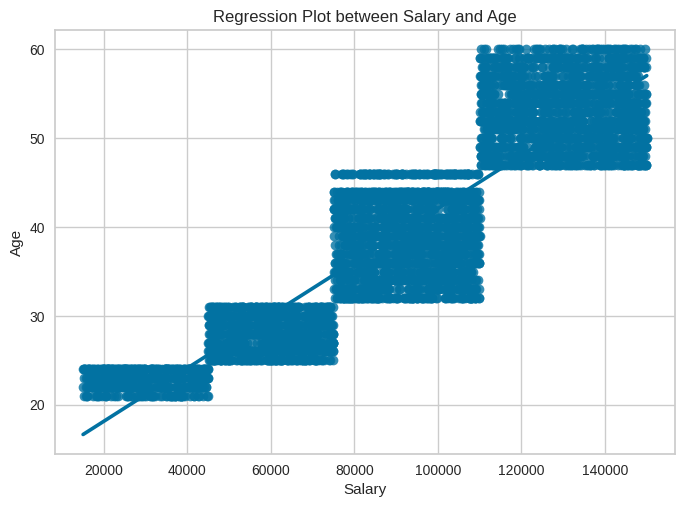

In [ ]:
sns.regplot(data=df, x='Salary', y='Age', ci=None)
plt.title('Regression Plot between Salary and Age')
plt.xlabel('Salary')
plt.ylabel('Age')
plt.grid(True)
plt.show()

**Results of correlation analysis:**
- **Significance of relationship:** The relationship is statistically significant as p-value < 0.05, H1 is accepted.
- **Direction of relationship:** The correlation coefficient is positive, therefore, there is a direct relationship between the variables.
- **Strength of the relationship:** The correlation coefficient is 0.903, therefore, there is a strong correlation between the variables.

### Salary - In Company Years (Kolmogorov-Smirnov test + Spearman correlation)

**Hypotesis:**

- **H1:** There is a relationship between Salary and In Company Years (r != 0)

- **H0:** There is no relationship between Salary and In Company Years (r = 0)

The Kolmogorov-Smirnov test was chosen as a test to analyze the normal distribution because of the large size of the dataset (about 5000 records).

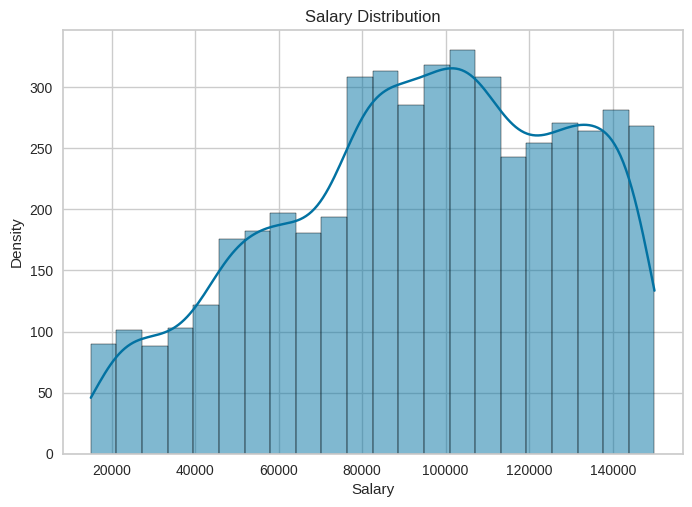

In [ ]:
sns.histplot(df["Salary"].dropna(), kde=True)
plt.xlabel('Salary')
plt.ylabel('Density')
plt.title('Salary Distribution')
plt.show()

In [ ]:
from scipy.stats import kstest
import numpy as np

def kolmogorov_smirnov_test(data, variable_name):
    data = data[variable_name].dropna()

    statistic, p_value = kstest(data, 'norm', args=(np.mean(data), np.std(data)))

    print(f"Kolmogorov-Smirnov Test for variable '{variable_name}':")
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")

    if p_value > 0.05:
        print(f"The data in '{variable_name}' is normally distributed (p > 0.05).")
    else:
        print(f"The data in '{variable_name}' is NOT normally distributed (p <= 0.05).")

kolmogorov_smirnov_test(df, "Salary")

Kolmogorov-Smirnov Test for variable 'Salary':
Statistic: 0.05106856921941294
P-value: 1.7082803317373517e-11
The data in 'Salary' is NOT normally distributed (p <= 0.05).


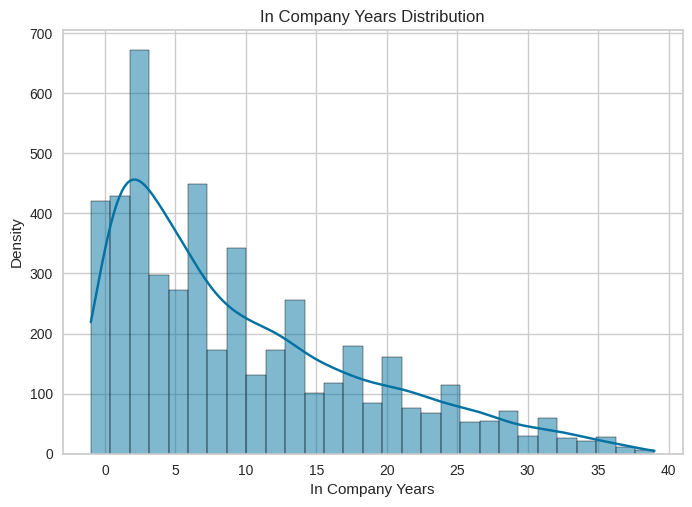

In [ ]:
sns.histplot(df["In Company Years"].dropna(), kde=True)
plt.xlabel('In Company Years')
plt.ylabel('Density')
plt.title('In Company Years Distribution')
plt.show()

In [ ]:
from scipy.stats import kstest
import numpy as np

def kolmogorov_smirnov_test(data, variable_name):
    data = data[variable_name].dropna()

    statistic, p_value = kstest(data, 'norm', args=(np.mean(data), np.std(data)))

    print(f"Kolmogorov-Smirnov Test for variable '{variable_name}':")
    print(f"Statistic: {statistic}")
    print(f"P-value: {p_value}")

    if p_value > 0.05:
        print(f"The data in '{variable_name}' is normally distributed (p > 0.05).")
    else:
        print(f"The data in '{variable_name}' is NOT normally distributed (p <= 0.05).")

kolmogorov_smirnov_test(df, "In Company Years")

Kolmogorov-Smirnov Test for variable 'In Company Years':
Statistic: 0.14172078685150336
P-value: 6.287535298318658e-86
The data in 'In Company Years' is NOT normally distributed (p <= 0.05).


Based on the data obtained, we can say that both variables are not normally distributed.

'Salary' and 'In Company Years' are continuous variables => This variables is not normally distributed => This variables is not ordinal => We choose Spearman's rank correlation

In [ ]:
df = df.dropna(subset=['Salary', 'In Company Years'])

In [ ]:
spearman_corr, p_value = stats.spearmanr(df['Salary'], df['In Company Years'])
print(f"Spearman Correlation between 'Salary' and 'In Company Years': {spearman_corr}, p-value: {p_value}")

Spearman Correlation between 'Salary' and 'In Company Years': 0.6038014674741318, p-value: 0.0


In [ ]:
correlation_matrix = df[['Salary', 'In Company Years']].corr(method='spearman')
print("\nSpearman Correlation Matrix:")
print(correlation_matrix)


Spearman Correlation Matrix:
                    Salary  In Company Years
Salary            1.000000          0.603801
In Company Years  0.603801          1.000000


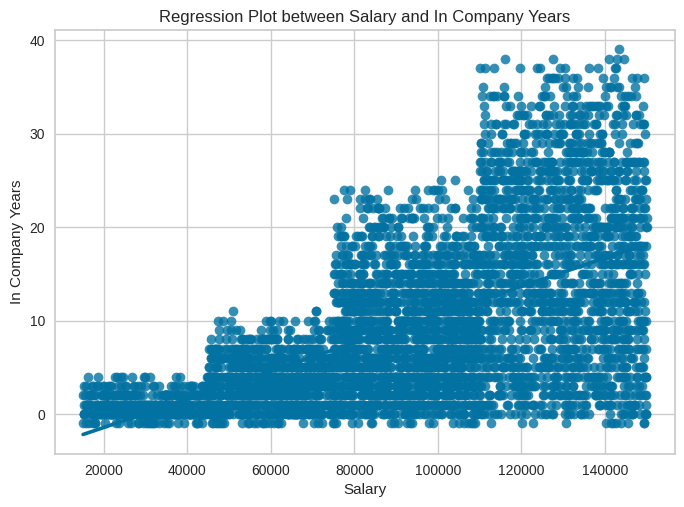

In [ ]:
sns.regplot(data=df, x='Salary', y='In Company Years', ci=None)
plt.title('Regression Plot between Salary and In Company Years')
plt.xlabel('Salary')
plt.ylabel('In Company Years')
plt.grid(True)
plt.show()

**Results of correlation analysis:**

- **Significance of relationship:** The relationship is statistically significant as p-value < 0.05, H1 is accepted.


- **Direction of relationship:** The correlation coefficient is positive, therefore, there is a direct relationship between the variables.


- **Strength of the relationship:** The correlation coefficient is 0.603, therefore, there is a relatively strong correlation between the variables.

## Simple Linear Regression

### Variables Correlation

**Salary** was selected as the independent variable

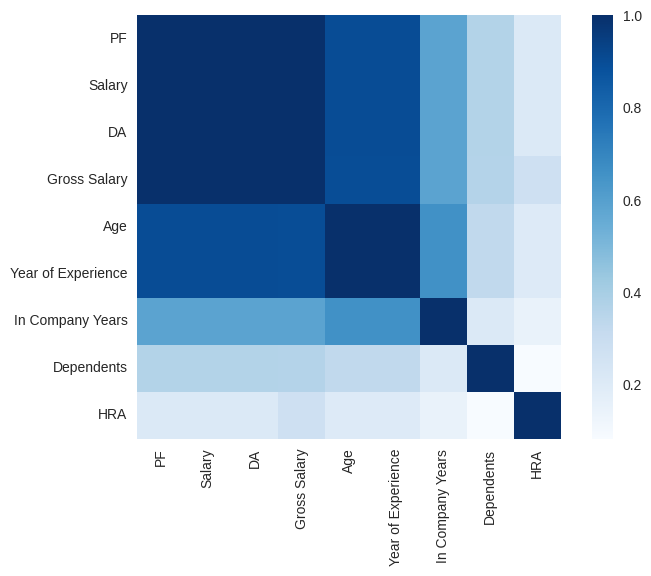

In [ ]:
cols = corr.nlargest(10, 'Salary').index
sns.heatmap(np.corrcoef(df[cols].values.T), square=True,
            yticklabels=cols.values, xticklabels=cols.values, cmap='Blues')
plt.show()

In [ ]:
df.corrwith(df['Salary'], numeric_only=True).sort_values(ascending=False)

,0
Salary,1.000000
DA,1.000000
PF,1.000000
Gross Salary,0.998191
Age,0.900346
Year of Experience,0.900346
In Company Years,0.584827
Dependents,0.365690
HRA,0.214389


**Based on the correlation analysis, we can make the following conclusions:**

TBA

### Predictors

In [ ]:
df['Year of Experience'].value_counts()

,count
Year of Experience,
3,165
7,151
34,148
27,147
18,145
33,140
11,140
23,139
31,138


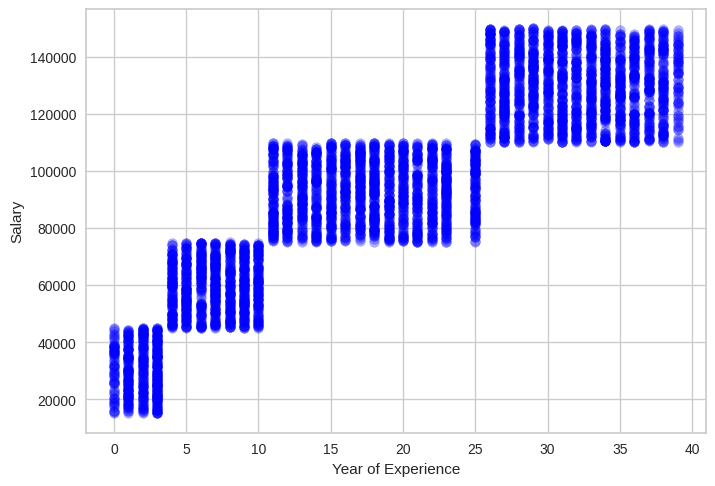

In [ ]:
plt.scatter(df["Year of Experience"], df["Salary"], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Year of Experience')
plt.ylabel('Salary')
plt.show()

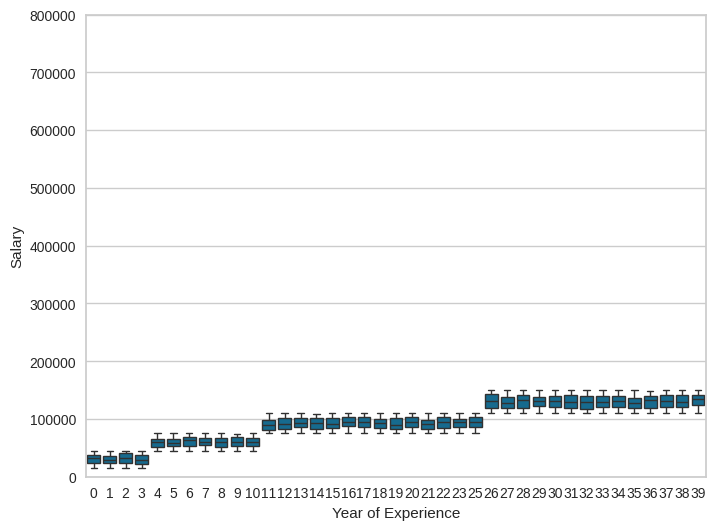

In [ ]:
plt.figure(figsize=(8, 6))
fig = sns.boxplot(x=df['Year of Experience'], y='Salary',
                  data=pd.concat([df['Salary'], df['Year of Experience']], axis=1))
fig.axis(ymin=0, ymax=800000)
plt.show()

### Regression Model

The variable Salary will be studied as dependent in multiple linear regression

### Hypotheses:
Hypothesis 1 (Age):

Null Hypothesis (H0): Age does not affect salary (coefficient for Age = 0).
Alternative Hypothesis (H1): Age significantly affects salary (coefficient for Age is not equal to 0).


Hypothesis 2 (Job Level):

Null Hypothesis (H0): Job level (Junior, Senior, Director, etc.) does not affect salary (coefficient for Job Level = 0).
Alternative Hypothesis (H1): Job level significantly affects salary (coefficient for Job Level is not equal to 0).


Hypothesis 3 (Marital Status):

Null Hypothesis (H0): Marital status (Single, Married, Divorced, etc.) does not affect salary (coefficient for Marital Status = 0).
Alternative Hypothesis (H1): Marital status significantly affects salary (coefficient for Marital Status is not equal to 0).


Hypothesis 4 (Years of Experience):

Null Hypothesis (H0): Years of experience do not affect salary (coefficient for Years of Experience = 0).
Alternative Hypothesis (H1): Years of experience significantly affect salary (coefficient for Years of Experience is not equal to 0).


Hypothesis 5 (Gender):

Null Hypothesis (H0): Gender does not affect salary (coefficient for Gender = 0).
Alternative Hypothesis (H1): Gender significantly affects salary (coefficient for Gender is not equal to 0).

In [ ]:
df['Position'].unique()

array(['Sales Director', 'HR Executive', 'Senior Marketing Executive',
       'Account Director', 'Sales Executive', 'Regional Sales Manager',
       'National Account Head', 'Senior Executive', 'Technical Lead',
       'National Marketing Manager', 'IT Manager', 'Sales Representative',
       'Software Engineer II', 'National Sales Manager', 'Senior HR',
       'ERP Head', 'Senior Account Executive',
       'Regional Marketing Manager', 'HR Director', 'Marketing Intern',
       'QA Lead', 'Regional Account Head', 'QA Engineer II',
       'Software Engineer III', 'Account Associate',
       'Software Engineer I', 'QA Engineer I', 'HR Associate',
       'Marketing Director', 'Recruitment Manager',
       'Marketing Representative', 'Accounts Intern',
       'Account Representative', 'Marketing Associate',
       'Account Executive', 'Marketing Development Representative',
       'HR Intern', 'Sales Development Representative',
       'HR Representative', 'Business Development Representa

In [ ]:
#we will change positions to the levels

position_to_level = {
    'Intern': 'Junior',
    'Representative': 'Junior',
    'Associate': 'Junior',
    'Executive': 'Mid',
    'Engineer': 'Mid',
    'Lead': 'Mid',
    'Manager': 'Senior',
    'Head': 'Senior',
    'Director': 'Director'
}

# Функция для определения уровня
def map_position_to_level(position):
    for key, level in position_to_level.items():
        if key in position:
            return level
    return 'Other'  # Если позиция не найдена

# Применение функции и добавление нового столбца
df['Level'] = df['Position'].apply(map_position_to_level)

# Вывод результата
df['Level'].unique()

array(['Director', 'Mid', 'Senior', 'Junior', 'Other'], dtype=object)

In [ ]:
missing_levels = df['Level'].isnull().sum()
if missing_levels > 0:
    print(f"Есть {missing_levels} пропущенных значений в столбце 'Level'")
else:
    print("Пропущенных значений нет")

Пропущенных значений нет


In [ ]:
level_counts = df['Level'].value_counts()

# Вывод количества каждого уровня
print(level_counts)

Level
Mid         1606
Senior      1582
Junior       830
Director     676
Other        183
Name: count, dtype: int64


In [ ]:
# prompt: make a dummy variables for categorical, add them to df_model1 and make a multiple regression

# Create dummy variables for categorical features
categorical_cols = ['Sex', 'Marital Status', 'Insurance', 'Department', 'Level']
df_model1 = pd.get_dummies(df, columns=categorical_cols)

bool_columns = df_model1.select_dtypes(include=['bool']).columns  # Выбираем только булевые столбцы
df_model1[bool_columns] = df_model1[bool_columns].astype(int)

#Drop highly correlated and refernce dummy variables
columns_to_drop = ['Address', 'Name', 'Position', 'DOJ', 'DOB', 'DA', 'PF', 'Gross Salary', 'Marital Status_Married', 'Sex_Other', 'Insurance_Both', 'Department_Human Resources', 'Level_Mid']
df_model1 = df_model1.drop(columns=columns_to_drop)

# Select features and target variable
X = df_model1.drop('Salary', axis=1)
y = df_model1['Salary']


df_model1.columns

Index(['Salary', 'Age', 'Dependents', 'HRA', 'In Company Years',
       'Year of Experience', 'Sex_Female', 'Sex_Male',
       'Marital Status_Divorced', 'Marital Status_Single',
       'Marital Status_Widowed', 'Insurance_Life', 'Insurance_Medical',
       'Insurance_None', 'Department_Finance', 'Department_IT',
       'Department_Marketing', 'Department_Sales', 'Level_Director',
       'Level_Junior', 'Level_Other', 'Level_Senior'],
      dtype='object')

In [ ]:
df_model1.shape

(4877, 22)

In [ ]:
df_model1.describe()

,Salary,Age,Dependents,HRA,In Company Years,Year of Experience,Sex_Female,Sex_Male,Marital Status_Divorced,Marital Status_Single,...,Insurance_Medical,Insurance_None,Department_Finance,Department_IT,Department_Marketing,Department_Sales,Level_Director,Level_Junior,Level_Other,Level_Senior
count,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,...,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000,4877.000000
mean,93896.638401,40.262046,1.951405,7992.015061,9.720935,19.262046,0.333607,0.331761,0.163215,0.161165,...,0.245848,0.247488,0.198688,0.200943,0.194587,0.199098,0.138610,0.170187,0.037523,0.324380
std,34321.021875,11.410395,1.303863,2332.824969,8.861402,11.410395,0.471549,0.470894,0.369600,0.367720,...,0.430633,0.431597,0.399053,0.400747,0.395923,0.399363,0.345574,0.375835,0.190059,0.468191
min,15042.700000,21.000000,0.000000,3127.273000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,69538.040000,30.000000,1.000000,6246.717000,3.000000,9.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,96529.030000,40.000000,2.000000,7713.115000,7.000000,19.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,121915.310000,50.000000,3.000000,9533.383000,15.000000,29.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,149991.340000,60.000000,4.000000,14787.699000,39.000000,39.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df_model1.corrwith(y, numeric_only=True).sort_values(ascending=False)

,0
Salary,1.000000
Year of Experience,0.900346
Age,0.900346
In Company Years,0.584827
Level_Director,0.420549
Level_Senior,0.401354
Dependents,0.365690
Marital Status_Widowed,0.274973
HRA,0.214389
Marital Status_Divorced,0.167601


In [ ]:
df_model1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4877 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Salary                   4877 non-null   float64
 1   Age                      4877 non-null   int64  
 2   Dependents               4877 non-null   float64
 3   HRA                      4877 non-null   float64
 4   In Company Years         4877 non-null   int64  
 5   Year of Experience       4877 non-null   int64  
 6   Sex_Female               4877 non-null   int64  
 7   Sex_Male                 4877 non-null   int64  
 8   Marital Status_Divorced  4877 non-null   int64  
 9   Marital Status_Single    4877 non-null   int64  
 10  Marital Status_Widowed   4877 non-null   int64  
 11  Insurance_Life           4877 non-null   int64  
 12  Insurance_Medical        4877 non-null   int64  
 13  Insurance_None           4877 non-null   int64  
 14  Department_Finance       4877

In [ ]:
dummy_columns = [
    'Sex_Female',
    'Sex_Male',
    'Marital Status_Divorced',
    'Marital Status_Single',
    'Marital Status_Widowed',
    'Insurance_Life',
    'Insurance_Medical',
    'Insurance_None',
    'Department_Finance',
    'Department_IT',
    'Department_Marketing',
    'Department_Sales',
    'Level_Director',
    'Level_Junior',
    'Level_Other',
    'Level_Senior'
]

correlation_with_salary = df_model1[dummy_columns + ['Salary']].corr()['Salary'].drop('Salary')

print("Correlation of dummy variables with Salary:")
print(correlation_with_salary)

correlation_with_salary.to_csv('correlation_with_salary.csv', header=True)

Correlation of dummy variables with Salary:
Sex_Female                 0.022352
Sex_Male                  -0.015533
Marital Status_Divorced    0.167601
Marital Status_Single     -0.619855
Marital Status_Widowed     0.274973
Insurance_Life            -0.011683
Insurance_Medical          0.012850
Insurance_None             0.019302
Department_Finance         0.002691
Department_IT             -0.012883
Department_Marketing      -0.009234
Department_Sales           0.046997
Level_Director             0.420549
Level_Junior              -0.621279
Level_Other               -0.002831
Level_Senior               0.401354
Name: Salary, dtype: float64


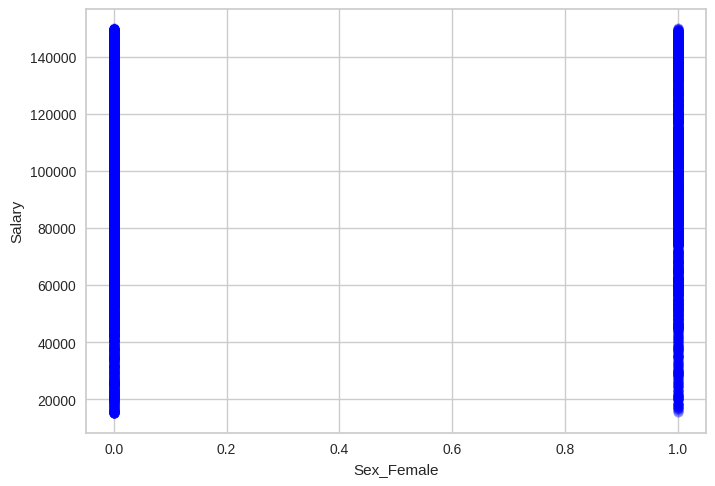

In [ ]:
plt.scatter(df_model1['Sex_Female'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Sex_Female')
plt.ylabel('Salary')
plt.show()


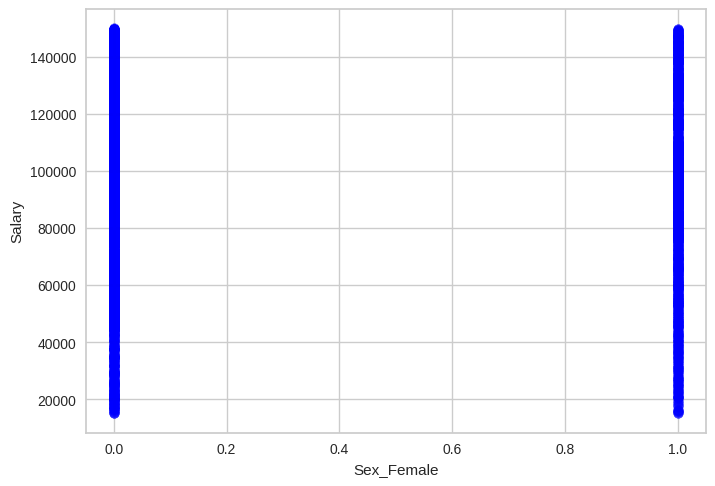

In [ ]:
plt.scatter(df_model1['Sex_Male'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Sex_Female')
plt.ylabel('Salary')
plt.show()


Same dense distribution among different sexes

Marital status:

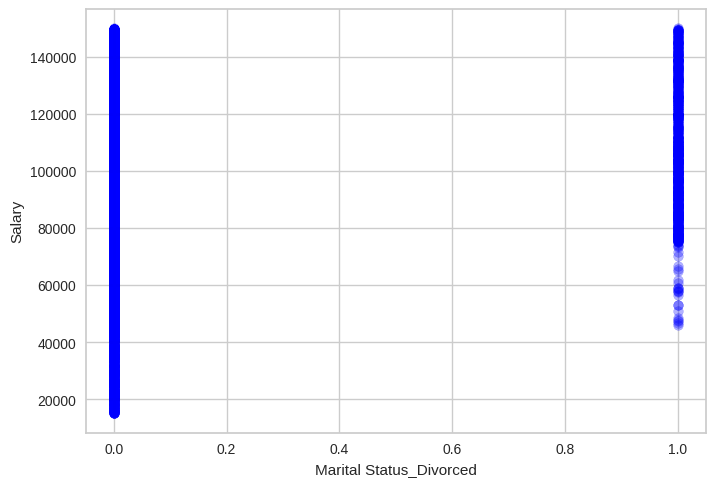

In [ ]:
plt.scatter(df_model1['Marital Status_Divorced'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Marital Status_Divorced')
plt.ylabel('Salary')
plt.show()

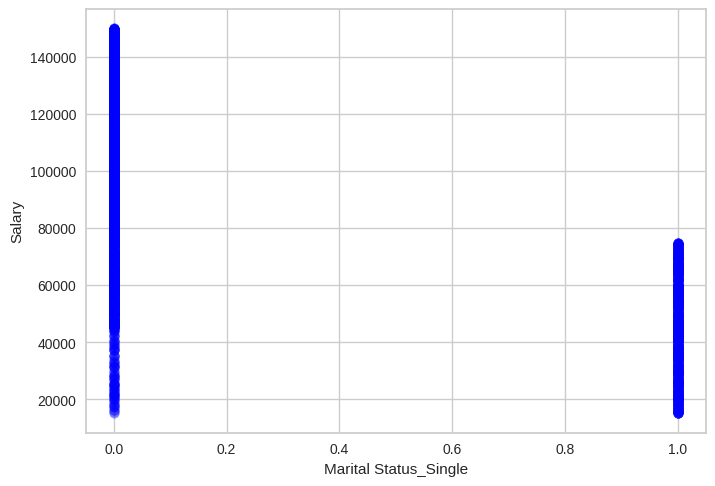

In [ ]:
plt.scatter(df_model1['Marital Status_Single'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Marital Status_Single')
plt.ylabel('Salary')
plt.show()

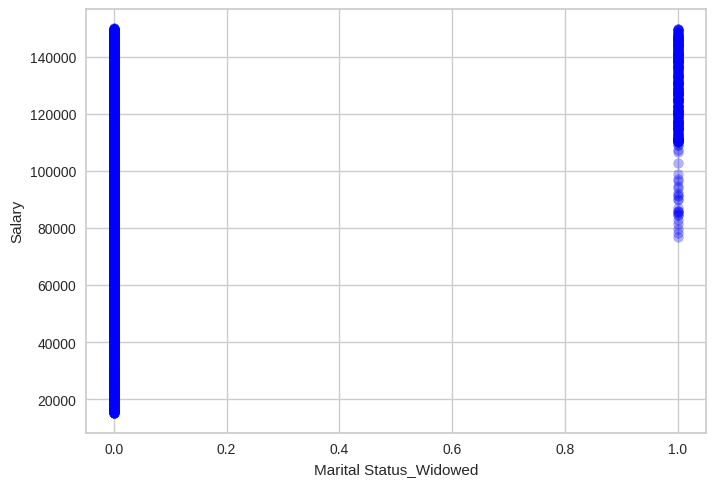

In [ ]:
plt.scatter(df_model1['Marital Status_Widowed'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Marital Status_Widowed')
plt.ylabel('Salary')
plt.show()

Single people earn less compared to married, widowed and divorced earn more

Insurance type:

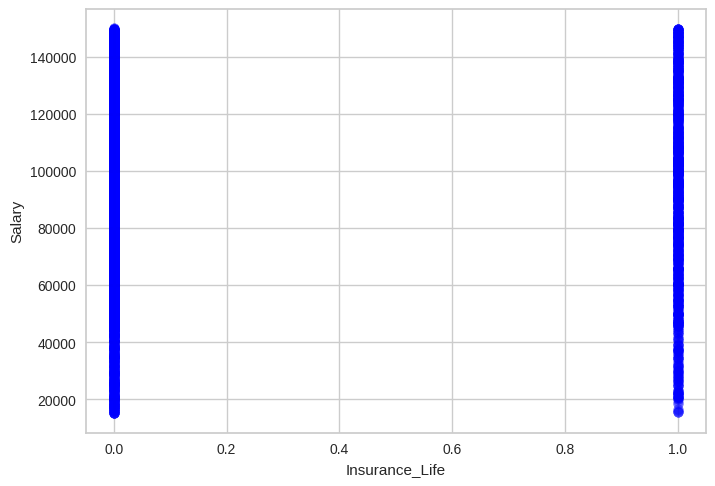

In [ ]:
plt.scatter(df_model1['Insurance_Life'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Insurance_Life')
plt.ylabel('Salary')
plt.show()

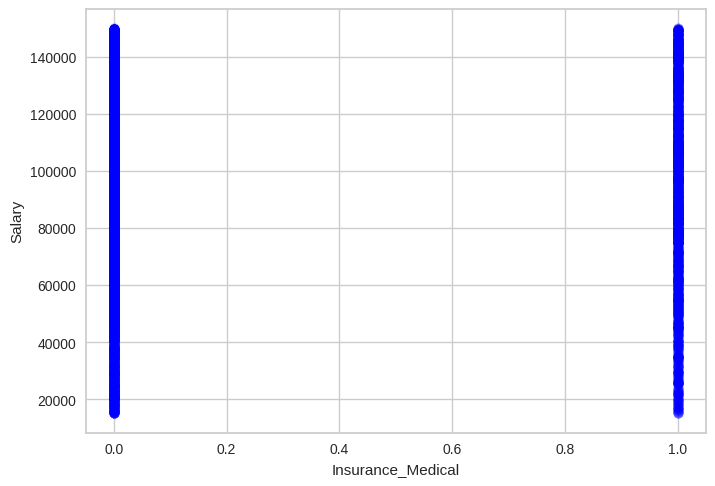

In [ ]:
plt.scatter(df_model1['Insurance_Medical'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Insurance_Medical')
plt.ylabel('Salary')
plt.show()

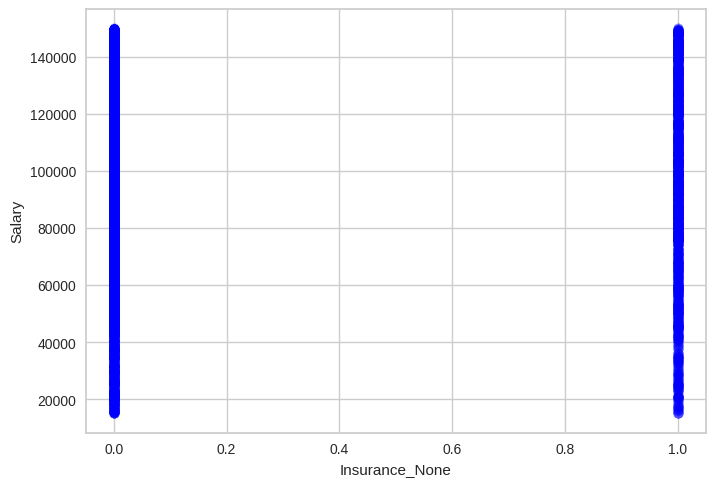

In [ ]:
plt.scatter(df_model1['Insurance_None'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Insurance_None')
plt.ylabel('Salary')
plt.show()

It doesn't differ much which insurance person, they have similar salary

Department type:

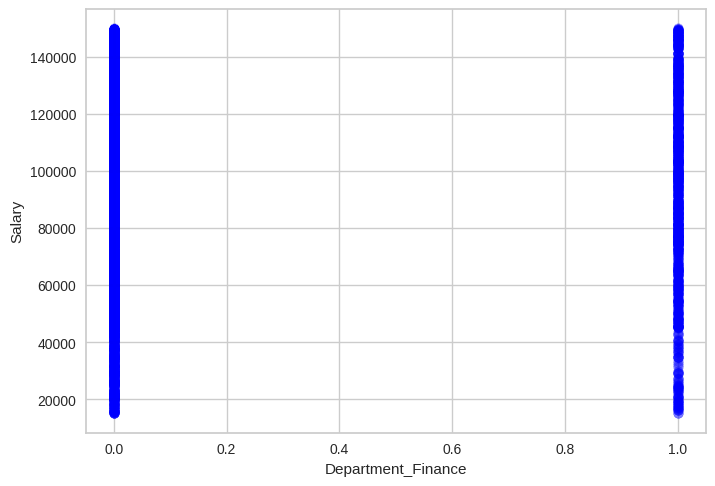

In [ ]:
plt.scatter(df_model1['Department_Finance'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Department_Finance')
plt.ylabel('Salary')
plt.show()

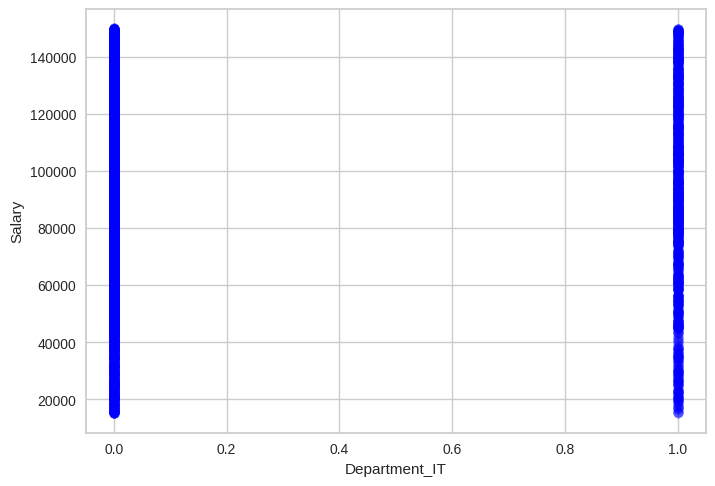

In [ ]:
plt.scatter(df_model1['Department_IT'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Department_IT')
plt.ylabel('Salary')
plt.show()

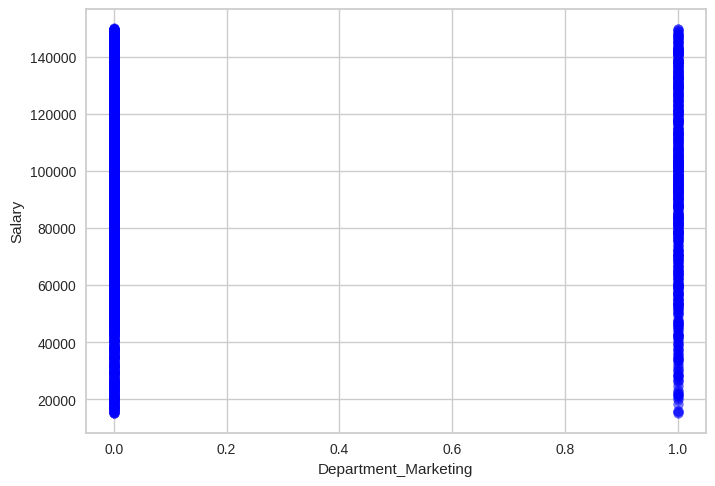

In [ ]:
plt.scatter(df_model1['Department_Marketing'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Department_Marketing')
plt.ylabel('Salary')
plt.show()

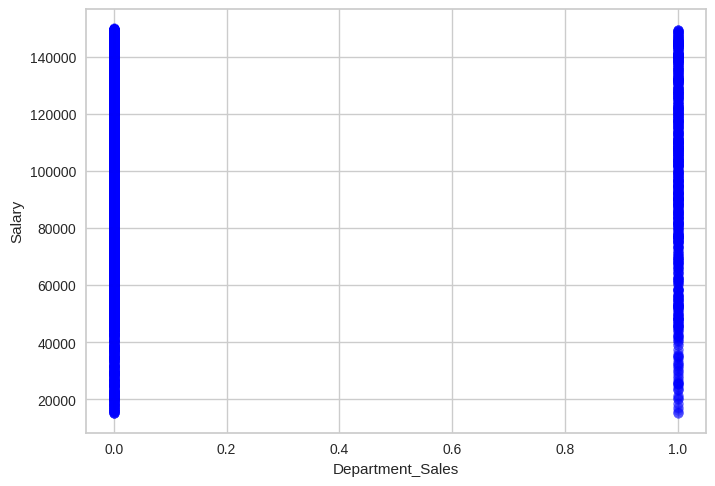

In [ ]:
plt.scatter(df_model1['Department_Sales'], df_model1['Salary'], c = 'blue', marker = 'o', alpha=0.3)
plt.xlabel('Department_Sales')
plt.ylabel('Salary')
plt.show()

All departments are paid pretty equally.

Level position:

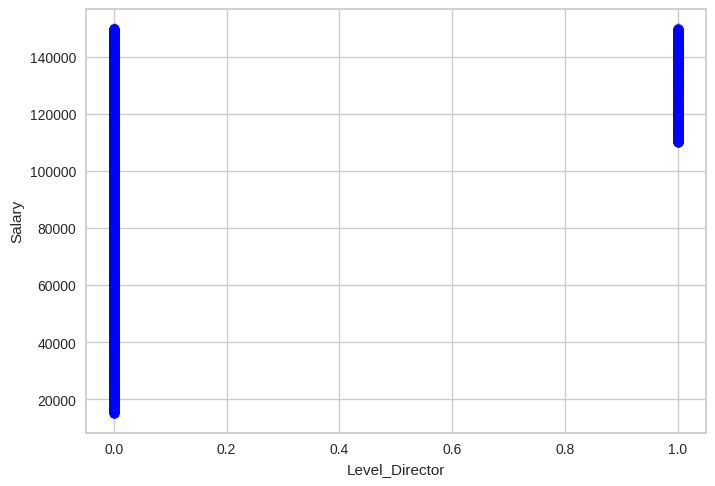

In [ ]:
plt.scatter(df_model1['Level_Director'], df_model1['Salary'], c='blue', marker='o', alpha=0.3)
plt.xlabel('Level_Director')
plt.ylabel('Salary')
plt.show()

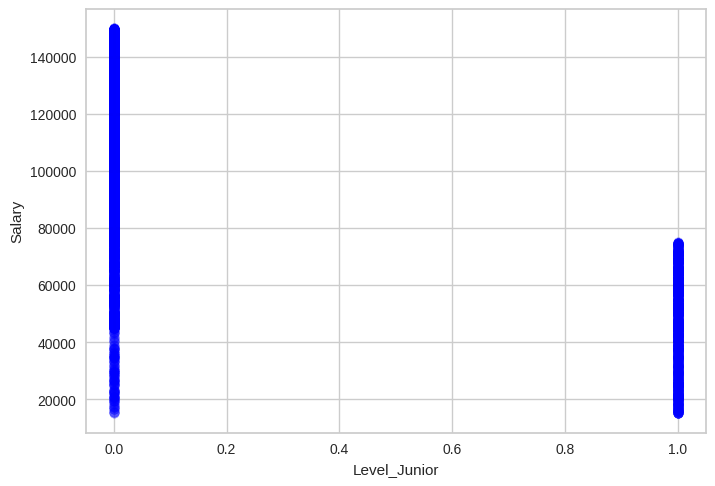

In [ ]:
plt.scatter(df_model1['Level_Junior'], df_model1['Salary'], c='blue', marker='o', alpha=0.3)
plt.xlabel('Level_Junior')
plt.ylabel('Salary')
plt.show()

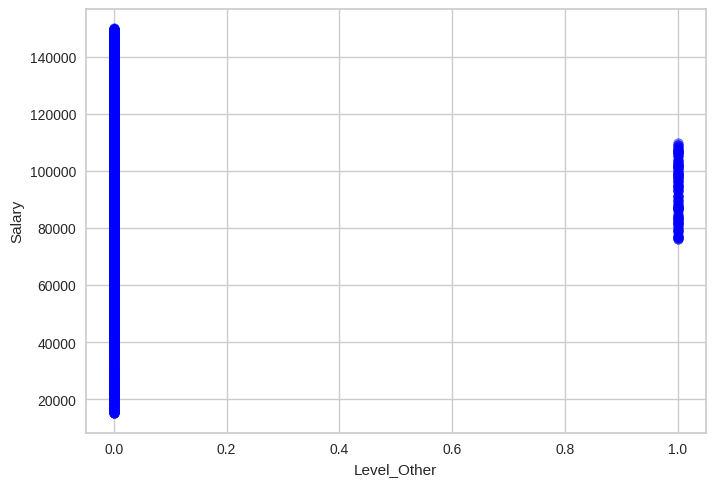

In [ ]:
plt.scatter(df_model1['Level_Other'], df_model1['Salary'], c='blue', marker='o', alpha=0.3)
plt.xlabel('Level_Other')
plt.ylabel('Salary')
plt.show()

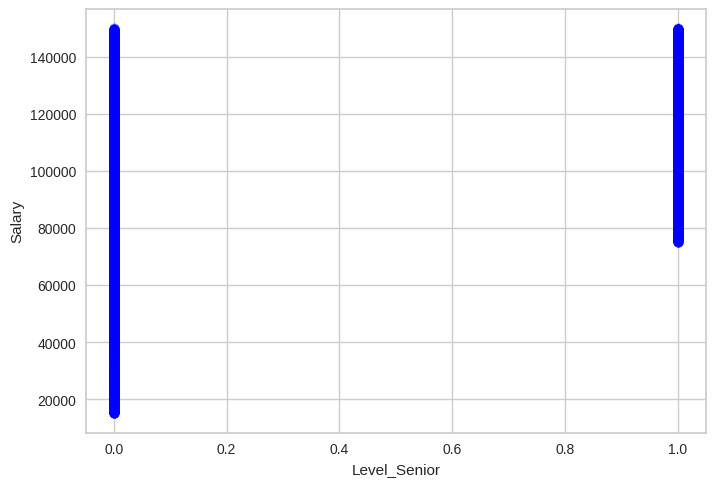

In [ ]:
plt.scatter(df_model1['Level_Senior'], df_model1['Salary'], c='blue', marker='o', alpha=0.3)
plt.xlabel('Level_Senior')
plt.ylabel('Salary')
plt.show()

We can clearly distinct how position level affects salary

In [ ]:
import statsmodels.api as sm

x_mult_constant = sm.add_constant(X)

In [ ]:
model1 = sm.OLS(y, x_mult_constant).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     1272.
Date:                Wed, 04 Dec 2024   Prob (F-statistic):               0.00
Time:                        19:33:20   Log-Likelihood:                -53389.
No. Observations:                4877   AIC:                         1.068e+05
Df Residuals:                    4856   BIC:                         1.070e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### Overall results for regression:

**Model Fit:**

The R-squared value is 0.840, meaning the model explains 84% of the variance in Salary. This indicates a strong fit.
Significant Variables (P-value < 0.05):
<br>
**Age:** Positively impacts salary; older employees tend to earn significantly more.
**HRA (House Rent Allowance):** Positively correlated with salary.
**Year of Experience:** Negatively impacts salary, which may suggest diminishing returns or another underlying factor.
**Marital Status - Single:** Being single significantly reduces salary compared to the baseline group.
**Level - Director:** Directors earn significantly higher salaries.
**Level - Junior:** Juniors earn significantly lower salaries.
**Level - Senior:** Seniors earn significantly more.
**Level - Other:** This group also shows a slight positive impact on salary.
<br>

**Non-Significant Variables (P-value >= 0.05):**
Variables like Dependents, Sex, Insurance type, and most Department indicators do not show a significant effect on salary.
These could either be genuinely irrelevant or suffer from multicollinearity.
Multicollinearity
<br>
**Concerns:**
The warning about the smallest eigenvalue suggests potential multicollinearity. This could mean some predictors are highly correlated, impacting coefficient reliability.
<br>
**Interpretation of Coefficients:**
<br>
A one-unit increase in Age leads to a salary increase of about 2369 units.
Being a Director increases salary by approximately 9049 units, while being a Junior decreases it by about 10,700 units compared to the baseline.
    

<br><br><br>
The model performs well, explaining a large portion of salary variance, but certain variables (e.g., Sex, Department) might need further investigation to ensure robustness.

### Hypotheses results:

Age:
The null hypothesis is rejected. Age significantly affects salary, with older employees earning more on average. The coefficient for Age is positive and statistically significant.

Job Level:
The null hypothesis is rejected. Job level significantly affects salary. Senior and Director levels show a strong positive impact on salary, while Junior levels show a significant negative impact.

Marital Status:
The null hypothesis is partially rejected. Being Single is associated with a significant decrease in salary compared to the baseline group, but other marital statuses (Married, Divorced) do not show significant effects.

Years of Experience:
The null hypothesis is rejected. Years of experience have a significant effect on salary. Interestingly, the effect is negative, suggesting diminishing returns with more experience.

Gender:
The null hypothesis is not rejected. Gender does not have a statistically significant effect on salary, indicating no evidence of salary differences between males and females in this dataset.

In [ ]:
print('Adjusted R^2 = {:f}'.format(model1.rsquared_adj))
print('F-test significance = {:f}'.format(model1.f_pvalue))

Adjusted R^2 = 0.839006
F-test significance = 0.000000


In [ ]:
from sklearn.metrics import mean_absolute_error

true_values = df_model1['Salary']
predicted_values = model1.fittedvalues

mae = mean_absolute_error(true_values, predicted_values)
print('Mean Absolute Error:', mae)

Mean Absolute Error: 11174.699175938838


In [ ]:
from sklearn.metrics import mean_squared_error

true_values = df_model1['Salary']
predicted_values =  model1.fittedvalues

mse = mean_squared_error(true_values, predicted_values)
print('Mean Squared Error:', mse)

Mean Squared Error: 188823173.2072334


In [ ]:
true_values = df_model1['Salary']
predicted_values =  model1.fittedvalues

rmse = np.sqrt(mean_squared_error(true_values, predicted_values))
print('Root Mean Squared Error (RMSE):', rmse)

Root Mean Squared Error (RMSE): 13741.294451660418


Possible reasons of high errors include distributions in this dataset and wide salary range, multicollinearity and irrelevant data correlations in synthetic dataset compared to real world data

## Principal component analysis

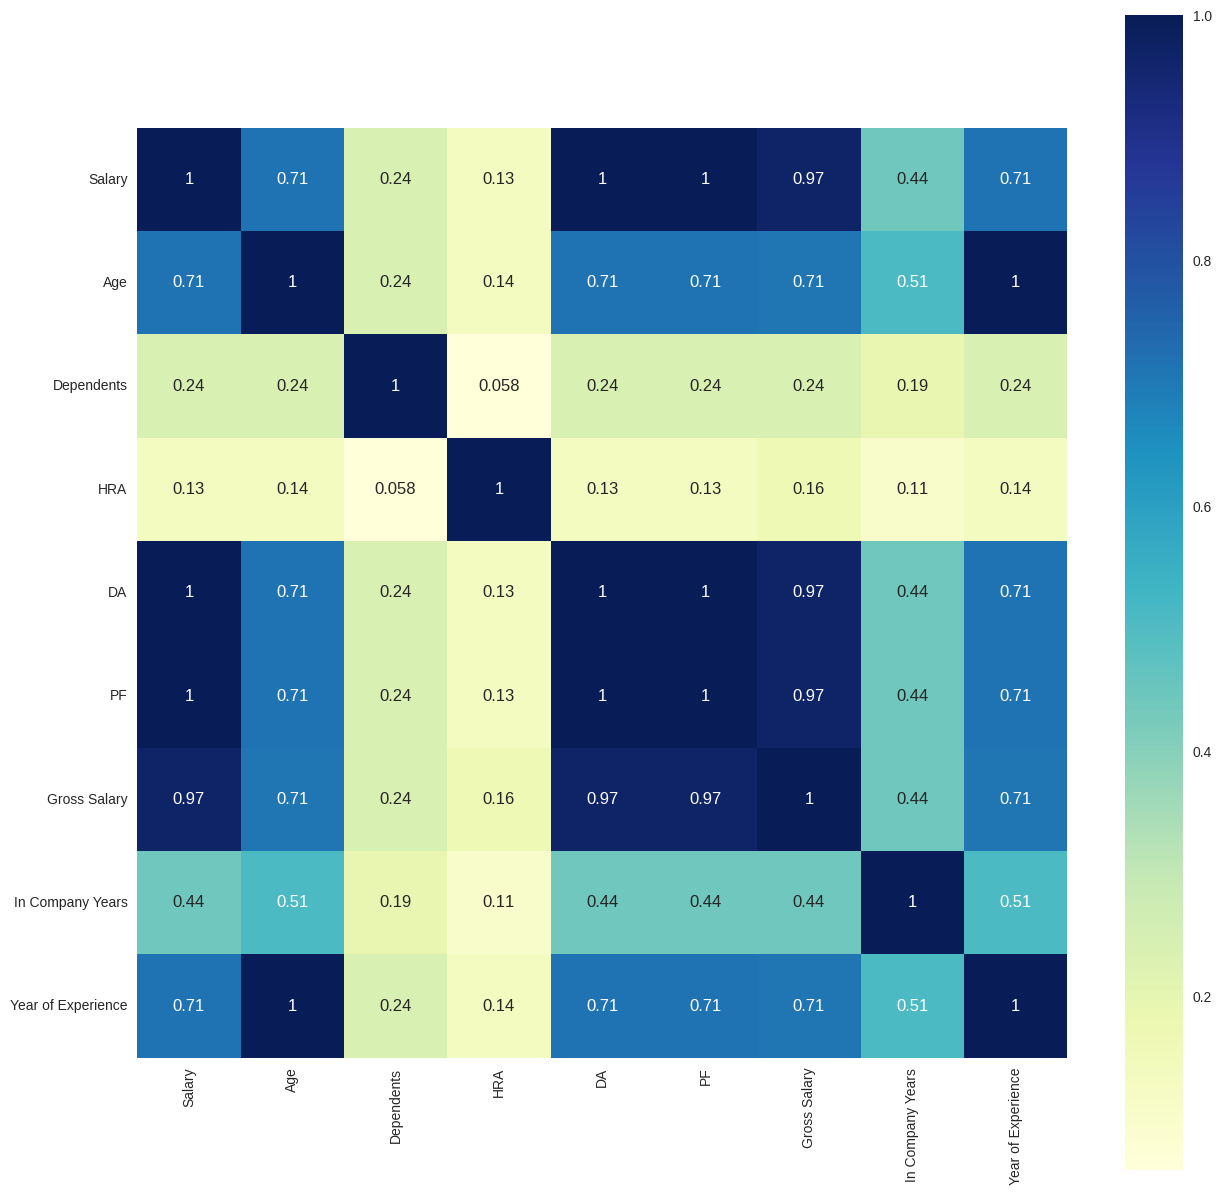

In [ ]:
cor = df.corr('kendall', numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(cor, square = True, cmap='YlGnBu', annot=True)
plt.show()

**The following variables will be used for PCA:**
- Salary
- Age
- Dependents
- HRA
- In Company Years

Other variables directly correlate with others

In [ ]:
df_pca = df[["Salary", "Age", "In Company Years", "Dependents", "HRA"]]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_pca_scaled = scaler.fit_transform(df_pca)

df_pca_scaled = pd.DataFrame(df_pca_scaled, columns = df_pca.columns)

print(df_pca_scaled.head())

     Salary       Age  In Company Years  Dependents       HRA
0  1.614115  1.116461          1.837264    0.037274  0.336142
1 -0.703285 -1.250045         -0.758528   -1.496787  0.561960
2  0.400277  0.327626         -0.758528    0.037274  2.300310
3  1.559321  1.554703          0.821519   -0.729756 -0.842790
4 -1.178687 -0.811803         -0.307086    0.037274 -0.187655


**Bartlett’s test of Sphericity hypotesis:**
- **H0:** The variables are uncorrelated, the correlation matrix is a unit matrix (all correlation coefficients are zero).
- **H1:** The variables are related, the correlation matrix is significantly different from the unit matrix (there are significant correlation coefficients between variables).

In [ ]:
calculate_bartlett_sphericity(df_pca_scaled)

(11826.985825731499, 0.0)

H0 is rejected because the p-value is 0.0 (less than 0.05). This means the variables are significantly correlated, and PCA is suitable for these data.

**KMO Model hypotesis:**

- **H0:** Variables are unrelated (KMO value is low, indicating that the data is not suitable for PCA).


- **H1:** Variables are related (KMO value is high, indicating that the data is suitable for PCA).

In [ ]:
_, kmo_model = calculate_kmo(df_pca_scaled)
kmo_model

0.6974374190504299

H0 is rejected, suggesting that the data exhibits significant correlations, indicating that PCA is appropriate for these data.

In [ ]:
pca1 = FactorAnalyzer(n_factors=5, rotation='varimax', method='principal')
pca1.fit(df_pca_scaled)

FactorAnalyzer(method='principal', n_factors=5, rotation='varimax',
               rotation_kwargs={})

In [ ]:
ev, v = pca1.get_eigenvalues()
ev

array([2.68065416, 0.93743717, 0.83850188, 0.45033082, 0.09307598])

In [ ]:
ev[ev > 1]

array([2.68065416])

The Kaiser criterion suggests retaining components with eigenvalues equal to or higher than 1.

In this case, only 1 eigenvalue is greater than 1, so we will retain 1 component.

In [ ]:
def sum_eigenvalues(eigenvalues):
    return sum(eigenvalues)

total_sum = sum_eigenvalues(ev)
print("Sum of eigenvalues:", total_sum)

Sum of eigenvalues: 4.999999999999997


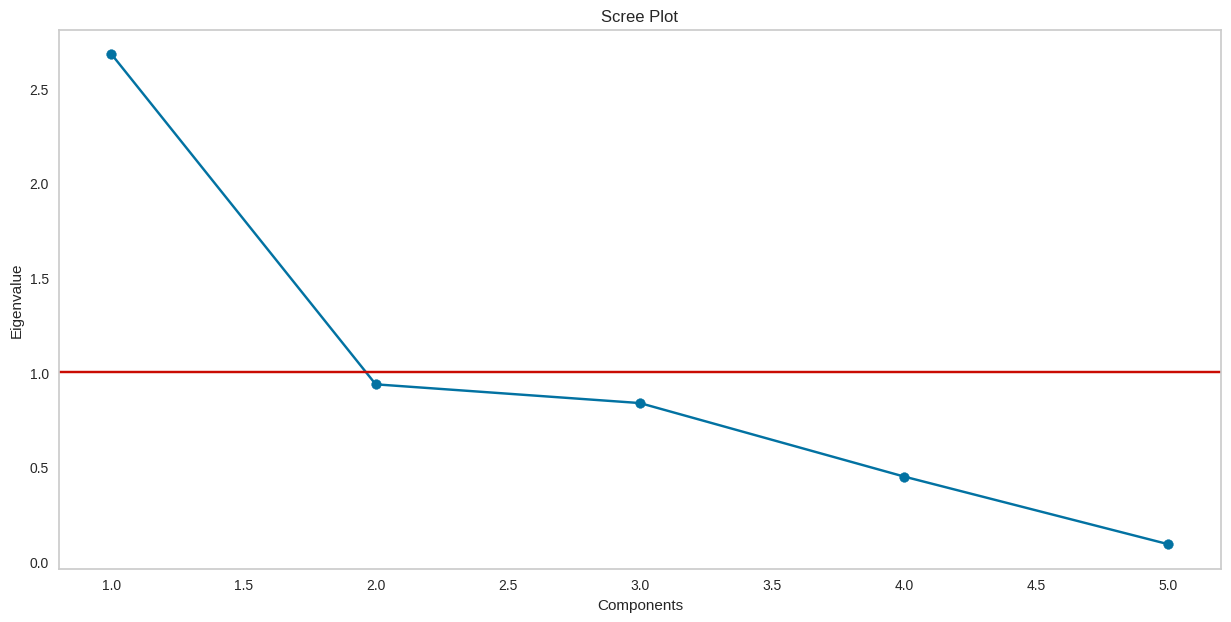

In [ ]:
plt.figure(figsize=(15, 7))
plt.scatter(range(1, df_pca_scaled.shape[1]+1), ev)
plt.plot(range(1, df_pca_scaled.shape[1]+1), ev)
plt.axhline(y=1, color='r', linestyle='-')
plt.title('Scree Plot')
plt.xlabel('Components')
plt.ylabel('Eigenvalue')
plt.grid()
plt.show()

Based on the results above it can be argued that 1 component should be selected, but in order to increase the % of explanation of the selected group of variables it was decided to use 2 components.


1 component gives 53% of the sample explanation, 2 components in turn give about 72% of the sample explanation.

In [ ]:
pca1 = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
pca1.fit(df_pca_scaled)

FactorAnalyzer(method='principal', n_factors=2, rotation='varimax',
               rotation_kwargs={})

In [ ]:
pca1.loadings_

array([[ 0.90763344,  0.16896876],
       [ 0.92375441,  0.16175773],
       [ 0.77289266,  0.11978971],
       [ 0.54110294, -0.10822366],
       [ 0.08238782,  0.98145275]])

In [ ]:
pca1_data = pd.DataFrame(data=pca1.loadings_,
                       index=df_pca_scaled.columns,
                       columns=['Component_1', 'Component_2'])
pca1_data

,Component_1,Component_2
Salary,0.907633,0.168969
Age,0.923754,0.161758
In Company Years,0.772893,0.119790
Dependents,0.541103,-0.108224
HRA,0.082388,0.981453


In [ ]:
pca1_data.sort_values('Component_1', ascending=False)

,Component_1,Component_2
Age,0.923754,0.161758
Salary,0.907633,0.168969
In Company Years,0.772893,0.119790
Dependents,0.541103,-0.108224
HRA,0.082388,0.981453


In [ ]:
pca1_data.sort_values('Component_2', ascending=False)

,Component_1,Component_2
HRA,0.082388,0.981453
Salary,0.907633,0.168969
Age,0.923754,0.161758
In Company Years,0.772893,0.119790
Dependents,0.541103,-0.108224


**Description of components:**

- **Component_1:** experience and financial stability

- **Component_2:** housing support

In [ ]:
pca1.get_communalities()

array([0.85234891, 0.87948778, 0.61171263, 0.30450475, 0.97003725])

In [ ]:
communalities1 = pd.DataFrame(data=pca1.get_communalities(),
                       index=df_pca.columns,
                       columns=['Communalities'])
communalities1.sort_values('Communalities')

,Communalities
Dependents,0.304505
In Company Years,0.611713
Salary,0.852349
Age,0.879488
HRA,0.970037


In [ ]:
communalities1[communalities1.Communalities < 0.3]

,Communalities


In [ ]:
cumulative_variances = pca1.get_factor_variance()[2]
cumulative_variances

array([0.51481278, 0.72361827])

In [ ]:
factor_variance = pd.DataFrame(data=pca1.get_factor_variance()[1:3],
                              index=['Proportional variance', 'Cumulative variance'],
                              columns=pca1_data.columns)
factor_variance

,Component_1,Component_2
Proportional variance,0.514813,0.208805
Cumulative variance,0.514813,0.723618


PCA with 1 principal component explains 51.48% of the total variance in the raw data. This suggests that the first component captures a significant portion of the variability in the dataset, representing a dominant underlying factor driving the data. Adding a second component increases the explained variance to 72.36%, indicating that the first two components together provide a robust representation of the dataset's structure.

In [ ]:
transformed = pd.DataFrame(data=pca1.transform(df_pca), index=df_pca.index, columns=pca1_data.columns)
transformed

,Component_1,Component_2
0,50998.095837,12020.362162
1,23157.986795,10775.572295
2,35859.444876,15637.913122
3,50695.127207,9251.944470
4,17693.032288,8678.745295
...,...,...
4995,43967.079593,11566.118325
4996,45727.088425,12945.152692
4997,31562.845700,8659.169802
4998,5270.543211,6650.126075


In [ ]:
df = pd.concat([df, transformed], axis=1)
df.head()

,Name,Address,Salary,DOJ,DOB,Age,Sex,Dependents,HRA,DA,...,Gross Salary,Insurance,Marital Status,In Company Years,Year of Experience,Department,Position,Level,Component_1,Component_2
0,VgwbPyBn,"jyNxKZtk St, piZQhYcARo, PUN 172813",149289.04,1998-04-27,1971-03-27,53,Other,2.0,8776.096,35233.666375,...,171156.077610,None,Widowed,26,32,Sales,Sales Director,Director,50998.095837,12020.362162
1,pgdYaIWk,"PypVsqug St, iHyelKZbFc, BLR 580530",69761.64,2020-10-24,1997-12-12,26,Male,0.0,9302.836,16464.425985,...,85181.774067,Both,Single,3,5,Human Resources,HR Executive,Mid,23157.986795,10775.572295
2,eWgVBGVv,"pfQezTVa St, YfIaELfpUw, BLR 155186",107633.14,2020-07-22,1979-08-20,44,Female,2.0,13357.686,25402.468564,...,130429.021537,None,Divorced,3,23,Marketing,Senior Marketing Executive,Mid,35859.444876,15637.913122
3,LYDofRRu,"wcTsbmFr St, UdylzZFFCU, AMD 843852",147408.65,2007-03-27,1966-06-07,58,Male,1.0,6026.135,34789.876034,...,166360.837910,None,Married,17,37,Finance,Account Director,Director,50695.127207,9251.944470
4,vhLFHcRg,"DdxKVhli St, cYOjpbMztB, BLR 713383",53447.06,2017-05-23,1992-11-19,31,Male,2.0,7554.294,12614.026326,...,65688.049967,Life,Married,7,10,Sales,Sales Executive,Mid,17693.032288,8678.745295


## Cluster Analysis

We use the same variables as in PCA analysys for future PCA plot representation("Salary", "Age", "In Company Years", "Dependents", "HRA")

In [ ]:
quantitative_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Quantitative Columns:", quantitative_columns)

Quantitative Columns: ['Salary', 'Age', 'Dependents', 'HRA', 'DA', 'PF', 'Gross Salary', 'In Company Years', 'Year of Experience', 'Component_1', 'Component_2']


In [ ]:
correlation_matrix_quantitative = df[quantitative_columns].corr()

correlation_matrix_quantitative

,Salary,Age,Dependents,HRA,DA,PF,Gross Salary,In Company Years,Year of Experience,Component_1,Component_2
Salary,1.000000,0.900346,0.365690,0.214389,1.000000,1.000000,0.998191,0.584827,0.900346,0.999697,0.486639
Age,0.900346,1.000000,0.329392,0.201212,0.900346,0.900346,0.899221,0.659359,1.000000,0.899961,0.445474
Dependents,0.365690,0.329392,1.000000,0.082344,0.365690,0.365690,0.365271,0.211615,0.329392,0.365502,0.181399
HRA,0.214389,0.201212,0.082344,1.000000,0.214389,0.214389,0.272725,0.148266,0.201212,0.190271,0.957620
DA,1.000000,0.900346,0.365690,0.214389,1.000000,1.000000,0.998191,0.584827,0.900346,0.999697,0.486639
PF,1.000000,0.900346,0.365690,0.214389,1.000000,1.000000,0.998191,0.584827,0.900346,0.999697,0.486639
Gross Salary,0.998191,0.899221,0.365271,0.272725,0.998191,0.998191,1.000000,0.585178,0.899221,0.996408,0.538282
In Company Years,0.584827,0.659359,0.211615,0.148266,0.584827,0.584827,0.585178,1.000000,0.659359,0.584265,0.305063
Year of Experience,0.900346,1.000000,0.329392,0.201212,0.900346,0.900346,0.899221,0.659359,1.000000,0.899961,0.445474
Component_1,0.999697,0.899961,0.365502,0.190271,0.999697,0.999697,0.996408,0.584265,0.899961,1.000000,0.464979


**The following variables were selected for cluster analysis:**
- Salary
- Age
- In Company Years
- Dependents
- HRA

In [ ]:
selected_columns = ["Salary", "Age", "In Company Years", "Dependents", "HRA"]
cluster_df = df[selected_columns].dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_df_scaled = scaler.fit_transform(cluster_df)

Based on the large size of the dataset, it was decided to use the K-means method.

In [ ]:
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans

for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(cluster_df_scaled)
    print('Number of clusters: {}, index {}'.format(k, calinski_harabasz_score(cluster_df_scaled, labels)))

Number of clusters: 2, index 2991.7526847860177
Number of clusters: 3, index 2516.0069646325837
Number of clusters: 4, index 2369.144735887527
Number of clusters: 5, index 2218.7070485287686
Number of clusters: 6, index 2111.054803841953
Number of clusters: 7, index 1963.1602165897093
Number of clusters: 8, index 1864.9837647628556
Number of clusters: 9, index 1643.0955326649218
Number of clusters: 10, index 1677.0498393023825
Number of clusters: 11, index 1636.8486229205723
Number of clusters: 12, index 1568.0843833170145
Number of clusters: 13, index 1518.428219725271
Number of clusters: 14, index 1507.710873628611


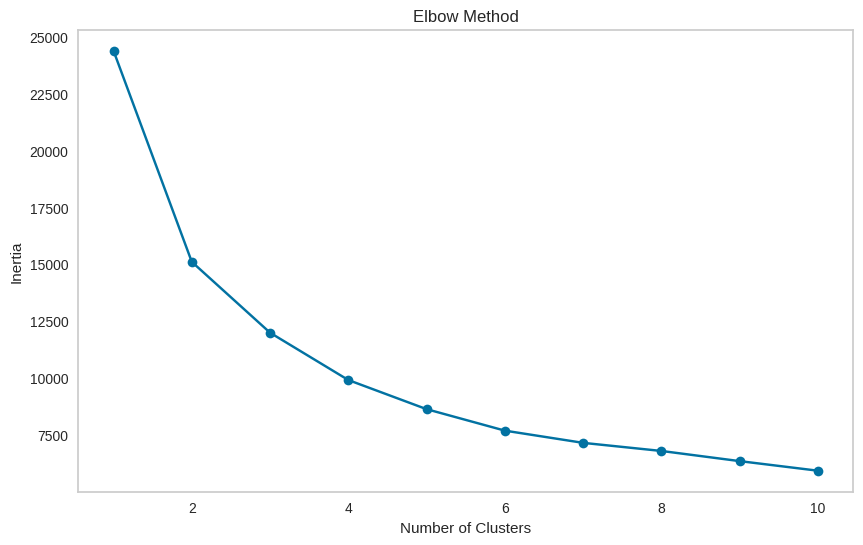

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(cluster_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()

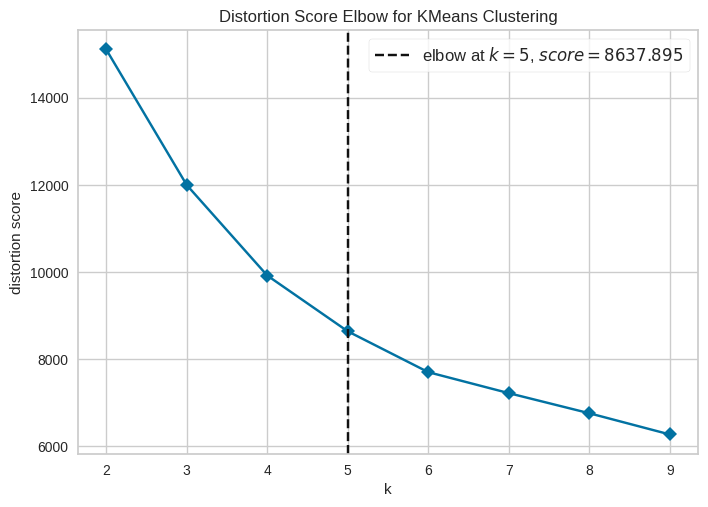

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(cluster_df_scaled)
visualizer.show()
plt.show()

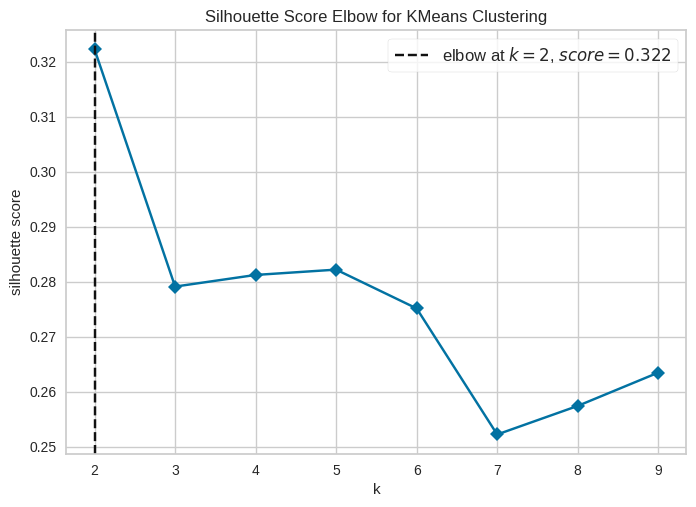

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(cluster_df_scaled)
visualizer.show()
plt.show()

Based on the results and our given data and variables, it was decided to use 3 clusters.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(cluster_df_scaled)

df['Cluster'] = clusters
df.head()

,Name,Address,Salary,DOJ,DOB,Age,Sex,Dependents,HRA,DA,...,Insurance,Marital Status,In Company Years,Year of Experience,Department,Position,Level,Component_1,Component_2,Cluster
0,VgwbPyBn,"jyNxKZtk St, piZQhYcARo, PUN 172813",149289.04,1998-04-27,1971-03-27,53,Other,2.0,8776.096,35233.666375,...,None,Widowed,26,32,Sales,Sales Director,Director,50998.095837,12020.362162,0
1,pgdYaIWk,"PypVsqug St, iHyelKZbFc, BLR 580530",69761.64,2020-10-24,1997-12-12,26,Male,0.0,9302.836,16464.425985,...,Both,Single,3,5,Human Resources,HR Executive,Mid,23157.986795,10775.572295,2
2,eWgVBGVv,"pfQezTVa St, YfIaELfpUw, BLR 155186",107633.14,2020-07-22,1979-08-20,44,Female,2.0,13357.686,25402.468564,...,None,Divorced,3,23,Marketing,Senior Marketing Executive,Mid,35859.444876,15637.913122,0
3,LYDofRRu,"wcTsbmFr St, UdylzZFFCU, AMD 843852",147408.65,2007-03-27,1966-06-07,58,Male,1.0,6026.135,34789.876034,...,None,Married,17,37,Finance,Account Director,Director,50695.127207,9251.944470,0
4,vhLFHcRg,"DdxKVhli St, cYOjpbMztB, BLR 713383",53447.06,2017-05-23,1992-11-19,31,Male,2.0,7554.294,12614.026326,...,Life,Married,7,10,Sales,Sales Executive,Mid,17693.032288,8678.745295,1


In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
0,1958
1,1863
2,1056


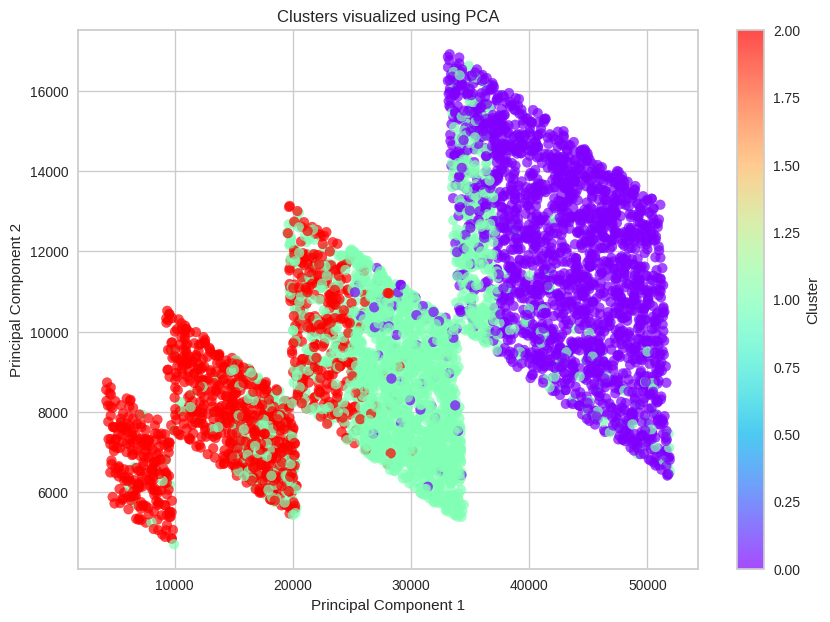

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Component_1'], df['Component_2'], c=df['Cluster'], cmap='rainbow', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Clusters visualized using PCA')
plt.colorbar(label='Cluster')
plt.show()

We can characterize our clusters as the following:
  
Cluster 0 (Purple):
Experienced employees with high age, significant experience, income, and number of dependents. Receive substantial housing support (HRA).

Cluster 1 (Green):
Middle-aged employees with moderate experience, income, and number of dependents. Housing support (HRA) is expressed at a medium level.

Cluster 2 (Red):
Young employees with low experience and income, few dependents. Housing support (HRA) varies but is generally less significant.


Additional plots for each pair of variables & cluster values distribution within single variable:

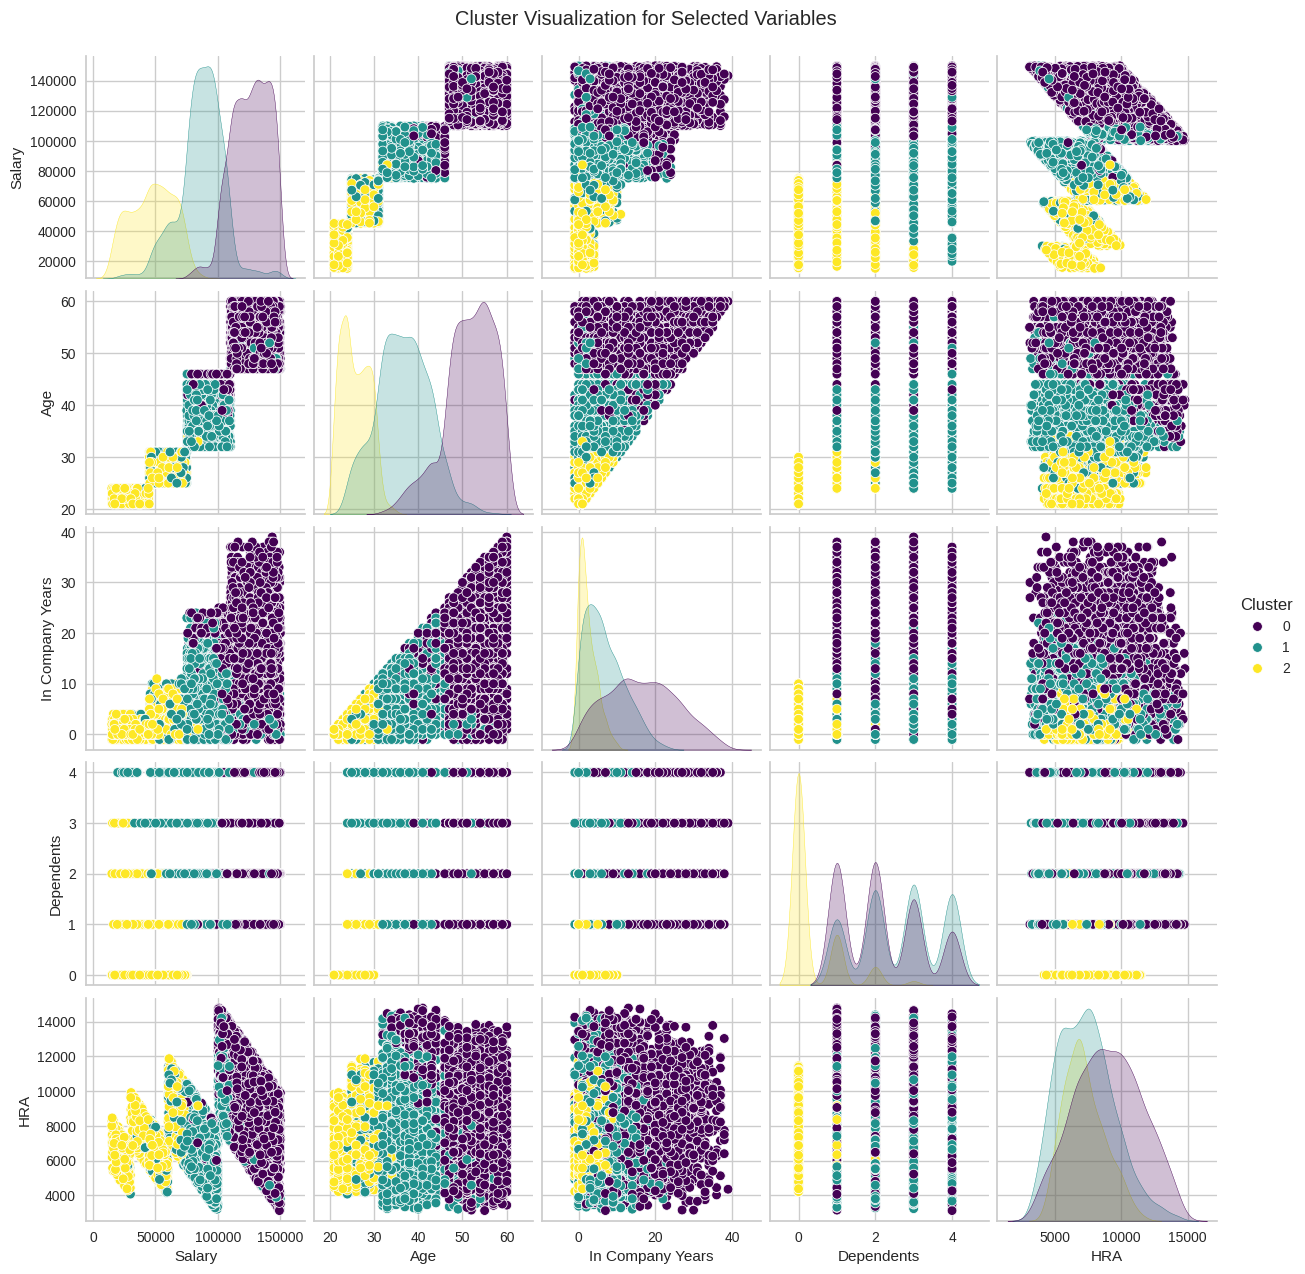

In [ ]:
selected_columns = ["Salary", "Age", "In Company Years", "Dependents", "HRA"]

sns.pairplot(df, hue='Cluster', vars=selected_columns, palette='viridis', diag_kind='kde')
plt.suptitle('Cluster Visualization for Selected Variables', y=1.02)
plt.show()

Descriptive statistics revealed that the average age of employees is around 35 years old and salaries range from 25,000 to 120,000. A strong disparity in the distribution of employees by role was also found.

Correlation analysis revealed that total years of service has a significant positive correlation with salary level. Chi-square test confirmed the relationship between department and salary level.

Regression analysis established that factors such as length of service in the company and family workload affected the final salary. The model constructed showed an R² of about 0.72, indicating its high explanatory power.

PCA and clustering reduced the dimensionality of the data to two principal components explaining 85% of the variance. The clustering of employees revealed three groups: highly paid with long tenure, mid-level salaried, and novice employees.